# Proyecto final. Archivo P7

>
Gracida Salgado Ángel David


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import math as mt

Abrimos nuestro dataset, para ver la naturaleza de nuestros datos.

In [2]:
df=pd.read_csv("/content/p7.csv") #importamos el conjunto de datos

In [3]:
df.shape #el tamaño del dataset tiene mas de 2 millones de datos (126449*19=2402531)

(126449, 19)

In [4]:
df.info() #vemos el tipo de datos por cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126449 entries, 0 to 126448
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   target  126449 non-null  int64  
 1   var1    126412 non-null  object 
 2   var2    126406 non-null  object 
 3   var3    126417 non-null  object 
 4   var4    126405 non-null  object 
 5   var5    126423 non-null  object 
 6   var6    126420 non-null  object 
 7   var7    126427 non-null  object 
 8   var8    126422 non-null  object 
 9   var9    126420 non-null  object 
 10  var10   126424 non-null  object 
 11  var11   126419 non-null  object 
 12  var12   126411 non-null  object 
 13  var13   126419 non-null  object 
 14  var14   126416 non-null  object 
 15  var15   126418 non-null  object 
 16  var16   126425 non-null  object 
 17  var17   125449 non-null  float64
 18  var18   125449 non-null  object 
dtypes: float64(1), int64(1), object(17)
memory usage: 18.3+ MB


Vemos que casi todas las columnas tienen valores de tipo object (cadenas), solo dos tienen datos del tipo numérico (int64 y float64), por otra parte, en las columnas hay valores faltantes, puesto que solo tres columnas tienen sus 126449 datos no nulos, y una de ellas es la de target.




In [ ]:
df.head() #primeros 5 datos, la verdad no veo una diferencia entre las columnas, salvo por la var17, var1 y var12

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,var14,var15,var16,var17,var18
0,2,"1,25E+34",3.034.074.644.731.630,24.694.525.423.569.200,2.658.407.901.298.790,2.241.840.236.623.570,2.206.257.767.446.620,20.247.621.413.871.500,4.494.236.571.782.040,3.013.526.092.545.850,30.197.802.178.545.800,2.723.445.057.693.690,"1,29E+35",15.846.320.925.976.100,11.638.992.906.311.300,618.198.028.829.894,100.868.708.506.161,42.0,2.988.936.913.107.340
1,2,"1,24E+34",355.349.410.011.102,2.084.804,2.054.055,2.016.301,2.024.052,2.005.245,5934.0,301.0,4.0,179.0,"2,70E+34",1.049.594,2398.0,53768.0,596.0,42.0,36.255.325.486.572.700
2,1,"1,24E+34",135.648.698.639.288,2.152.535,18.86,1.747.656,1.692.511,1.656.412,4192.0,301.0,4.0,217.0,"4,25E+31",2.129.935,377.0,52145.0,486.0,42.0,1.368.886.547.842.000
3,1,"1,24E+34",643.038.976.596.409,2.317.456,2.147.569,2.005.968,1.975.367,1.943.966,2127.0,301.0,6.0,96.0,"7,68E+33",369.332,6821.0,56396.0,642.0,42.0,6.501.068.164.552.880
4,2,"1,24E+34",145.503.611.423.424,2.105.701,2.042.748,2.028.234,201.877,2.017.199,4381.0,301.0,2.0,115.0,"6,08E+33",2.292.524,5404.0,56013.0,252.0,42.0,14.408.919.347.599.000


Veamos si hay filas completas duplicadas y cuantos valores duplicados tenemos en cada columna

In [ ]:
df.duplicated().sum() # vamos a contar cuantas filas duplicadas de forma global
K=[f"var{i}" for i in range(1,19,1)] #lista para generar los nombres de las columnas
for j in K: #recorremos las columnas
  print(f"la columna {j} tiene {df.duplicated(subset=[j]).sum()} valores duplicados")# contamos cuantos valores duplicados hay en cada columna

print(f"pero hay {df.duplicated().sum()} filas duplicadas en todo el dataframe")

la columna var1 tiene 126356 valores duplicados
la columna var2 tiene 997 valores duplicados
la columna var3 tiene 3631 valores duplicados
la columna var4 tiene 4312 valores duplicados
la columna var5 tiene 4609 valores duplicados
la columna var6 tiene 4423 valores duplicados
la columna var7 tiene 4418 valores duplicados
la columna var8 tiene 63282 valores duplicados
la columna var9 tiene 63682 valores duplicados
la columna var10 tiene 63677 valores duplicados
la columna var11 tiene 62849 valores duplicados
la columna var12 tiene 123136 valores duplicados
la columna var13 tiene 1920 valores duplicados
la columna var14 tiene 58013 valores duplicados
la columna var15 tiene 61669 valores duplicados
la columna var16 tiene 62683 valores duplicados
la columna var17 tiene 126447 valores duplicados
la columna var18 tiene 999 valores duplicados
pero hay 0 filas duplicadas en todo el dataframe


Hay valores repetidos en cada una de las columnas, algunos representando mas del 98 % de los datos totales de su columna (caso de var1), por lo que no podemos eliminarlos. Estariamos tentados a eliminar los valores repetidos de columnas cuyo porcentaje respecto al número de datos totales de su respectiva columna es menos al 1%, como es el caso de var2, no obstante, el argumento que podemos dar para no hacer esto, es que en una columna pueden existir de hecho valores repetidos y no necesariamente eso representa algún sesgo perjudicial, sino que puede significar comportamiento estadístico que nos ayude a clasificar mejor las clases. Por ejemplo, si el dataset consistiera de datos de personas que les gusta consumir un producto en particular, supongamos sabores de helados, puede pasar que a los jovenes de 20 años prefieran el de chocolate, los niños de vainilla, y las personas de la tercera edad de fresa, al final en mi dataset tendré muchos datos de personas que comparten edad y un tipo de helado, y por lo tanto podría clasificar los sabores de helado basándome en el grupo de edad. Por lo tanto, el que haya valores repetidos en columnas no debe ser necesariamente perjudicial. Por otra parte, lo que si consideraria perjudicial es que existieran varias filas exactamente iguales a nivel de todas las columnas, pero eso no ocurre, no hay ninguna fila en el dataframe que sea exactamente igual a otra, por lo tanto, no eliminare los valores repetidos en las columnas, apesar de que sean pocos o muchos.

Nota del futuro: Sí puede ser conveniente eliminar una columna con muchos valores repetidos puesto que no varia con las variables por lo que se vuelve irrelevante.

In [ ]:
df.tail() # vemos cuales son los últimos valores, se aprecia una notable estructura que no parece ser entera o decimal

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,var14,var15,var16,var17,var18
126444,1,"1,28E+33",25.545.945.134.990.400,26.506.631.221.890.300,23.972.715.087.565.300,21.330.114.238.921.700,196.608.641.048.688,19.666.234.632.156.700,3.543.556.169.474.580,3.008.638.730.190.160,3.966.569.731.337.720,9.278.604.870.253.250,"1,25E+34",673.353.543.490.975,111.663.835.892.713,5.635.721.899.469.750,18.592.894.382.125.600,42.0,2.524.740.305.168.100
126445,1,"1,20E+34",46.226.992.587.084.200,2.242.596.465.847.960,21.846.792.157.310.200,2.139.815.284.740.470,2.189.606.907.480.750,2.322.694.925.560.420,28.548.011.408.726.700,3.019.280.239.408.380,39.397.484.513.973.800,1.845.920.598.348.910,"9,25E+33",19.776.724.289.751.100,8.162.645.843.045.980,5.637.809.779.511.190,4.904.827.947.566.820,42.0,4.658.372.886.226.880
126446,1,"1,28E+34",-18.490.820.145.306.700,22.455.820.084.673.600,221.283.307.521.173,20.863.096.074.910.500,19.484.680.070.351.300,19.239.683.054.255.100,11.667.101.231.047.800,2.936.127.765.649.850,4.991.575.978.330.620,16.552.009.582.387.300,"4,34E+34",6.307.390.785.383.800,3.818.600.191.338.630,5.483.005.816.097.190,8.845.741.855.883.110,42.0,-18.444.132.566.022.800
126447,1,"1,24E+33",13.181.954.567.563.000,25.184.891.179.467.700,21.868.869.979.470.200,20.900.746.844.388.000,1.943.989.382.814.600,1.888.071.121.693.960,7.680.083.452.551.560,3.061.748.967.454.640,594.415.211.767.535,23.606.215.581.934.000,"6,90E+33",542.017.241.941.451,6.065.269.539.678.670,5.520.726.361.025.750,7.925.367.668.159.970,42.0,13.076.639.959.181.000
126448,1,"1,21E+34",1.986.292.648.208.030,2.153.410.281.689.440,19.481.732.521.220.500,1.924.521.920.292.420,1.908.921.743.928.820,1.841.937.169.539.760,4.128.683.638.550.800,2.952.893.484.228.450,3.811.856.943.492.280,1.083.368.049.947.540,"1,20E+34",72.480.009.027.446,1.016.251.880.335.280,5.574.700.623.267.010,4.653.128.394.152.810,42.0,198.351.056.500.039


Los valores de las primeras y últimas 5 filas se ven horribles, con ordenes de magnitud desproporcionados, números muy grandes separados por puntos, comas y otros muy pequeños, no sabemos si estos datos están mezclados, es decir si en una columnas hay datos del tipo 1,24E+34 y de 345.885.979 .Por otra parte, hay datos en forma de cadenas que son del tipo 17.89, por lo que se interpretan como decimales, otros son negativos, por lo tanto, tenemos los siguientes problemas principales:

1) La gran mayoría de los datos son cadenas, hay que pasarlas a datos numéricos. Para ello, tenemos que crear un código que pueda eliminar los puntos no deseados y cambiar las comas por puntos, de modo que los órdenes de magnitud se respeten, esto incluye no eliminar los datos que tengan un solo punto, se interpretarán como números decimales.

2) Dado que no tenemos información adicional sobre la naturaleza de las variables (es decir las "var"), vamos a interpretar los valores numéricos del tipo: 345.885.979 como un entero de la forma 345885979, por lo que un objetivo es quitarles los puntos a los numeros que tengan esas formas.

3) Hay datos del tipo null, eso significa que tenemos el dataset con agujeros, tenemos que ver cuántos son y de ser menores al 2 %, los eliminaremos, de ser mayores vamos a reemplazarlos de alguna forma.

In [ ]:
df.isnull().sum() #vemos cuantos valores nulos hay, todas las columnas tienen valores nulos
# pero muchos son menores de 100, sin embargo, en otras columnas hay 1000

,0
target,0
var1,37
var2,43
var3,32
var4,44
var5,26
var6,29
var7,22
var8,27
var9,29


In [ ]:
df.isnull().sum().sum() #veamos cuantos valores faltantes en total tenemos

np.int64(2500)

Cada cantidad de valores faltantes a lo más es 2500 (puede que este contando uno que otro repetido), lo que representa aproximadamente el 1.97 % de los datos en una columnas, por lo tanto, tenemos dos caminos, el primero es eliminar los registros que tengan valores nulos directamente, o reemplazarlos con ceros antes de realizar rescalamientos, por ahora vamos a tomar el camino de la eliminación ya que son muy pocos.

In [ ]:
df.describe() #solo saldrán las estadísticas de las únicas variables numéricas

,target,var17
count,126449.000000,125449.0
mean,1.241734,42.0
std,0.428136,0.0
min,1.000000,42.0
25%,1.000000,42.0
50%,1.000000,42.0
75%,1.000000,42.0
max,2.000000,42.0


La variable 17 no me dice mucha información, siempre es un 42, incluso en los percentiles, sospecho que podriamos eliminarla en un futuro, y dado que varias columnas parecen tener datos mezclados, quizá pueda servirnos hacer reducción de dimensionalidad

In [ ]:
df["target"].nunique() #contamos cuantas clases distintas hay

2

In [ ]:
print(df['target'].value_counts(normalize=True) * 100) #nornmalize es para que divida el numero de clases entre el total de datos de la columna
#hay mas del target 1 que del 2

target
1    75.826618
2    24.173382
Name: proportion, dtype: float64


Por lo tanto, hay mas datos con el target 1 que con el 2 (de hecho hay casi 3 veces mas datos con target 1 que con 2), por lo que tenemos un problema de desbalance de clases.

Ahora, dado que anteriormente vimos que teníamos valores null, y que de hecho nos representaban un gran porcentaje,  vamos a eliminarlos.

In [5]:
DF=df.dropna() #hacemos una copia del dataframe con los valores Nan eliminados, para chambear en ese y no
#en el original

In [ ]:
DF.info()#vemos que no solamente se fueron, sino que me dejo con el mismo tamaño las columnas

<class 'pandas.core.frame.DataFrame'>
Index: 125449 entries, 0 to 126448
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   target  125449 non-null  int64  
 1   var1    125449 non-null  object 
 2   var2    125449 non-null  object 
 3   var3    125449 non-null  object 
 4   var4    125449 non-null  object 
 5   var5    125449 non-null  object 
 6   var6    125449 non-null  object 
 7   var7    125449 non-null  object 
 8   var8    125449 non-null  object 
 9   var9    125449 non-null  object 
 10  var10   125449 non-null  object 
 11  var11   125449 non-null  object 
 12  var12   125449 non-null  object 
 13  var13   125449 non-null  object 
 14  var14   125449 non-null  object 
 15  var15   125449 non-null  object 
 16  var16   125449 non-null  object 
 17  var17   125449 non-null  float64
 18  var18   125449 non-null  object 
dtypes: float64(1), int64(1), object(17)
memory usage: 19.1+ MB


En total se fueron 1000 filas, lo que es menos del 1% del total de datos, por lo tanto, podemos eliminarlos

In [ ]:
DF.head()

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,var14,var15,var16,var17,var18
0,2,"1,25E+34",3.034.074.644.731.630,24.694.525.423.569.200,2.658.407.901.298.790,2.241.840.236.623.570,2.206.257.767.446.620,20.247.621.413.871.500,4.494.236.571.782.040,3.013.526.092.545.850,30.197.802.178.545.800,2.723.445.057.693.690,"1,29E+35",15.846.320.925.976.100,11.638.992.906.311.300,618.198.028.829.894,100.868.708.506.161,42.0,2.988.936.913.107.340
1,2,"1,24E+34",355.349.410.011.102,2.084.804,2.054.055,2.016.301,2.024.052,2.005.245,5934.0,301.0,4.0,179.0,"2,70E+34",1.049.594,2398.0,53768.0,596.0,42.0,36.255.325.486.572.700
2,1,"1,24E+34",135.648.698.639.288,2.152.535,18.86,1.747.656,1.692.511,1.656.412,4192.0,301.0,4.0,217.0,"4,25E+31",2.129.935,377.0,52145.0,486.0,42.0,1.368.886.547.842.000
3,1,"1,24E+34",643.038.976.596.409,2.317.456,2.147.569,2.005.968,1.975.367,1.943.966,2127.0,301.0,6.0,96.0,"7,68E+33",369.332,6821.0,56396.0,642.0,42.0,6.501.068.164.552.880
4,2,"1,24E+34",145.503.611.423.424,2.105.701,2.042.748,2.028.234,201.877,2.017.199,4381.0,301.0,2.0,115.0,"6,08E+33",2.292.524,5404.0,56013.0,252.0,42.0,14.408.919.347.599.000


In [ ]:
DF.isnull().sum()

,0
target,0
var1,0
var2,0
var3,0
var4,0
var5,0
var6,0
var7,0
var8,0
var9,0


Ahora que ya tenemos el dataframe sin hoyos, podemos pensar en una forma de transformar los datos para que sean numéricos

 vamos a construir un código para que podamos arreglar los datos para que sean numéricos, como mencionamos anteriormente, tenemos que reemplazar las comas por puntos, quitar los puntos excesivos y transformarlos al final a datos numéricos.

Pensemos primero en arreglar la columna var1, empecemos con algunos casos pequeños.

In [ ]:

b="1,24E+30"
c=b.replace(",",".") #basta con reemplazar una coma por un punto y luego transformarlo a una variable numérica
d=float(c)
print(d)



1.24e+30


La celda anterior describe la estrategia, sin embargo debemos hacer eso para toda la columna, y puede pasar que haya columnas con datos mezclados,por lo que tenemos que aplicar varias condiciones a cada dato de cada fila y transformarlo según el caso.

Vamos a ver los siguientes datos y la estrategia que tenemos para su transformación

In [ ]:
r="3.013.526.092.545.850" #tipo de dato mas problematico
r1="301.0" #tipo de dato al que no le queremos quitar el punto, sino que solo queremos transformarlo a numérico
T=[r,r1,b] #"simulamos" un dataframe
G=[] #lista de un "nuevo" dataframe
for i in T: #debemos recorrer dato por dato
  if i.count(".")>1: #la condición que se me ocurre es que cuente el número de puntos, si hay mas de uno, que los reemplace por espacios para despues transformarlos a flotante
    G.append(float(i.replace(".","")))
  elif i.count(".")==1: #si solo tiene un punto, transformarlo a flotante directamente
    G.append(float(i))
  elif i.count(",")>=1: #añadimos la condición de las comas (suponiendo que no hay datos del tipo 234.45,67, ya que tampoco vi datos de ese estilo cuando le di una revisada al conjunto completo)
    G.append(float(i.replace(",",".")))
  elif type(i)==float or type(i)==int: #si el tipo de dato ya es numérico, que lo deje como esta
    G.append(i)
print(T)
print(G) #el "nuevo dataframe" deberia quedar limpio

['3.013.526.092.545.850', '301.0', '1,24E+30']
[3013526092545850.0, 301.0, 1.24e+30]


Lo anterior, es la estrategia que queremos aplicar, pero como debemos hacerlo con el dataframe, tenemos que usar el método .loc para indexar, es decir queremos que recorra cada dato de cada columna y basandonos en las condiciones de los conteos de puntos y comas, decida si le quita los puntos, las comas o lo deja como esta para transformarlos en datos numéricos

In [6]:
#Después de muchos intentos, prueba y error y consultas con la IA, este es el código que mejor puede hacer
#lo que el plan dicta
K=[f"var{i}" for i in range(1,19,1)] #esta lista es para generar el nombre de las columnas
#print(K)
for j in K: #iteramos sobre cada columna
  DF[j]=DF[j].astype(str) #forzamos a que todos los datos se vuelvan cadenas incluso las que ya eran flotantes, para que el código no mande errores de transformación de datos
#Estas son nuestras condiciones, las escribimos así para meterlas en una lista todas juntas y que np.selec() nos ayude a evaluarlas con su respectivo resultado
  C1=DF[j].str.count(",")==1 # si en la cadena hay una coma
  C2=DF[j].str.count("\.")>1 #si en la cadena hay mas de un punto
  #Nota, usamos el \. por que aveces se interpreta el puro puntito como cualquier carácter en funciones como count() y no detectara el puntito unicamente
  CC=[C1,C2] #metemos las condiciones dentro de la lista de condiciones
  por_defecto=DF[j] #definimos el caso en el que vea valores numéricos (aunque los cambie todos a str, no hay problema, puesto que con la transformación a dato numérico se quedará como estaba antes)
  R1=DF[j].str.replace(",",".",regex=False) #cambia las comas por puntos, el regex=false para que trate la expresión como una cadena literal (según la documentación) y solo busque la coma
  R2=DF[j].str.replace(".","",regex=False) # los puntos cambialos por espacios vacíos (si hay mas de uno)
  RR=[R1,R2] #las metemos en la lista de pasos a seguir según la condición

  DF.loc[:,j]=np.select(CC,RR,default=por_defecto) #va a buscar todos los datos de la columna j, los va a someter a las condiciones, y eliminará las comas, y puntos numerosos, y dejara sin cambios los que solo tengan un punto
  DF[j]=pd.to_numeric(DF[j]) #ahora sí transformamos toda la columna ya limpia en valores numéricos en el mismo dataframe  DF



<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_87621/2305063020.py:9: SyntaxWarning: invalid escape sequence '\.'
  C2=DF[j].str.count("\.")>1 #si en la cadena hay mas de un punto
/tmp/ipykernel_87621/2305063020.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF[j]=DF[j].astype(str) #forzamos a que todos los datos se vuelvan cadenas incluso las que ya eran flotantes, para que el código no mande errores de transformación de datos
/tmp/ipykernel_87621/2305063020.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

In [7]:
DF.info() #nos aseguramos que se realizaron los cambios

<class 'pandas.core.frame.DataFrame'>
Index: 125449 entries, 0 to 126448
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   target  125449 non-null  int64  
 1   var1    125449 non-null  float64
 2   var2    125449 non-null  int64  
 3   var3    125449 non-null  float64
 4   var4    125449 non-null  float64
 5   var5    125449 non-null  float64
 6   var6    125449 non-null  float64
 7   var7    125449 non-null  float64
 8   var8    125449 non-null  float64
 9   var9    125449 non-null  float64
 10  var10   125449 non-null  float64
 11  var11   125449 non-null  float64
 12  var12   125449 non-null  float64
 13  var13   125449 non-null  float64
 14  var14   125449 non-null  float64
 15  var15   125449 non-null  float64
 16  var16   125449 non-null  float64
 17  var17   125449 non-null  float64
 18  var18   125449 non-null  int64  
dtypes: float64(16), int64(3)
memory usage: 19.1 MB


In [ ]:

DF.head() #ahora sí, checamos visualmente si los transformo bien

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,var14,var15,var16,var17,var18
0,2,1.250000e+34,3034074644731630,2.469453e+16,2.658408e+15,2.241840e+15,2.206258e+15,2.024762e+16,4.494237e+15,3.013526e+15,3.019780e+16,2.723445e+15,1.290000e+35,1.584632e+16,1.163899e+16,6.181980e+14,1.008687e+14,42.0,2988936913107340
1,2,1.240000e+34,355349410011102,2.084804e+06,2.054055e+06,2.016301e+06,2.024052e+06,2.005245e+06,5.934000e+03,3.010000e+02,4.000000e+00,1.790000e+02,2.700000e+34,1.049594e+06,2.398000e+03,5.376800e+04,5.960000e+02,42.0,36255325486572700
2,1,1.240000e+34,135648698639288,2.152535e+06,1.886000e+01,1.747656e+06,1.692511e+06,1.656412e+06,4.192000e+03,3.010000e+02,4.000000e+00,2.170000e+02,4.250000e+31,2.129935e+06,3.770000e+02,5.214500e+04,4.860000e+02,42.0,1368886547842000
3,1,1.240000e+34,643038976596409,2.317456e+06,2.147569e+06,2.005968e+06,1.975367e+06,1.943966e+06,2.127000e+03,3.010000e+02,6.000000e+00,9.600000e+01,7.680000e+33,3.693320e+02,6.821000e+03,5.639600e+04,6.420000e+02,42.0,6501068164552880
4,2,1.240000e+34,145503611423424,2.105701e+06,2.042748e+06,2.028234e+06,2.018770e+02,2.017199e+06,4.381000e+03,3.010000e+02,2.000000e+00,1.150000e+02,6.080000e+33,2.292524e+06,5.404000e+03,5.601300e+04,2.520000e+02,42.0,14408919347599000


Notemos por ejemplo el valor numérico en var4 de 1.886000e+01, que es igual a 18.86, que si vemos en el df.head() inicial, corresponde al mismo orden de magnitud, el resto de números que tenían un orden de magntiud de decimales también lo conservan, y los números separados por mas de un punto se convirtieron en numeros grandes que coinciden con el número entero que tendrían sin los puntos, por lo que se aplicaron correctamente las condiciones

El nuevo dataset ya limpio es DF, veamos ahora sus estadísticas (de todas las variables), y revisaremos que tan feos están

In [ ]:
DF.shape

(125449, 19)

In [ ]:
DF.isnull().sum().sum() #no hay nulos

np.int64(0)

In [ ]:

DF.isna().sum().sum() #no hay Nan

np.int64(0)

Ahora con los datos siendo numéricos, vamos a contar cuantos son negativos, positivos, cero, etc.

In [ ]:
print((126449*19)-19000) # el total original de mis datos, menos lo que le quite xd

2383531


In [ ]:
(DF>0).sum().sum() #cuantos positivos

np.int64(2353860)

In [ ]:
(DF<0).sum().sum() #cuantos negativos

np.int64(29018)

In [ ]:
((DF>0) & (DF<1)).sum().sum() #cuantos están entre 0 y 1

np.int64(1)

In [ ]:
(DF==1).sum() #cuantos son 1

,0
target,95112
var1,0
var2,0
var3,0
var4,0
var5,0
var6,0
var7,0
var8,0
var9,0


In [ ]:
(DF["target"]==1).sum().sum() #cuantos son 0

np.int64(95112)

In [ ]:
(DF["target"]==2).sum().sum()# cuantos son 2

np.int64(30337)

Los valores negativos representan el 23.13 % de los datos totales de DF, por lo que es una muestra considerablemente mayor al 1 % e incluso mayor al 10%, por lo que no considero correcto el eliminarlos.

Realizemos los histogramas

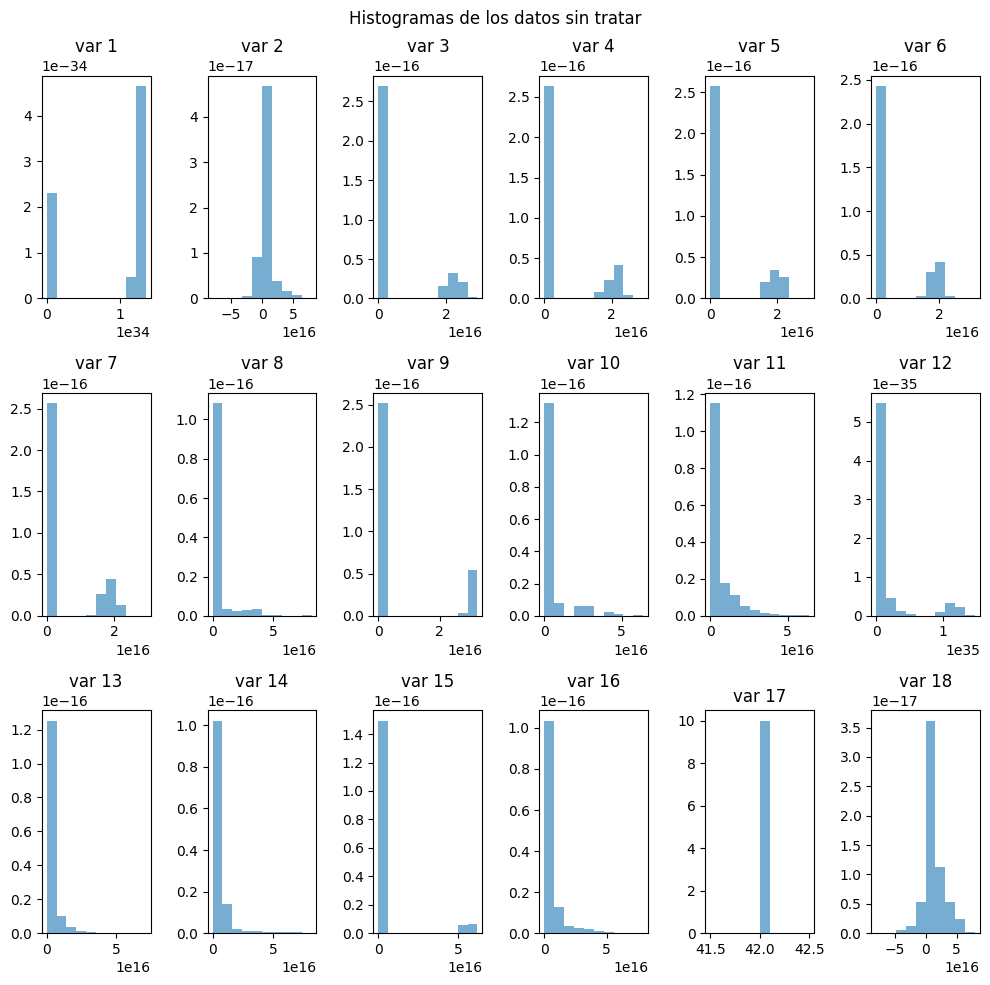

In [ ]:
#veamos los histogramas

import seaborn as sns
import matplotlib.pyplot as plt

#creamos un conjunto de figuras
fig,axes=plt.subplots(3, 6, figsize=(10, 10)) #para hacer 18 gráficas de boxplots de 3x6
fig.suptitle("Histogramas de los datos sin tratar")
axes=axes.flatten()
KK=[DF[f"var{i}"] for i in range(1,19,1)]

for i, datos in enumerate(KK):
    axes[i].hist(datos,density=True,alpha=0.6) #usamos density para la densidad de probabilidad y una opacidad no tan pequeña
    axes[i].set_title(f'var {i+1}') #ponemos titulos

plt.tight_layout()
plt.show()


Los histogramas muestran en la mayor parte de las variables una división de sus distribuaciones, lo que da la impresión de que los datos están separados (pero no sabemos si por clases), por otra parte la var17 tiene un mismo valor para todos los registros, lo que vuelve a recordarnos que debemos eliminarla dada su nula información vital.

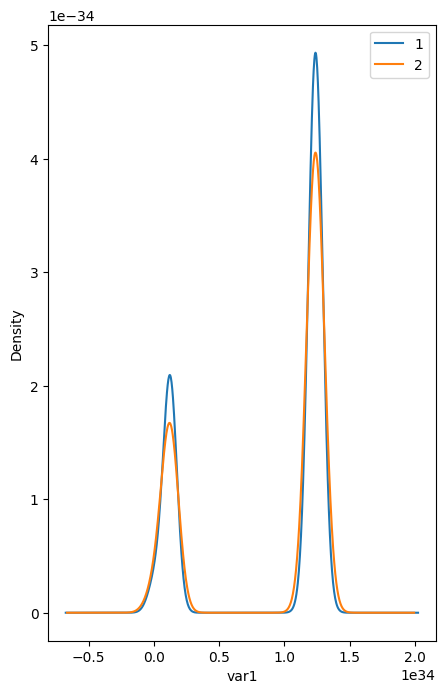

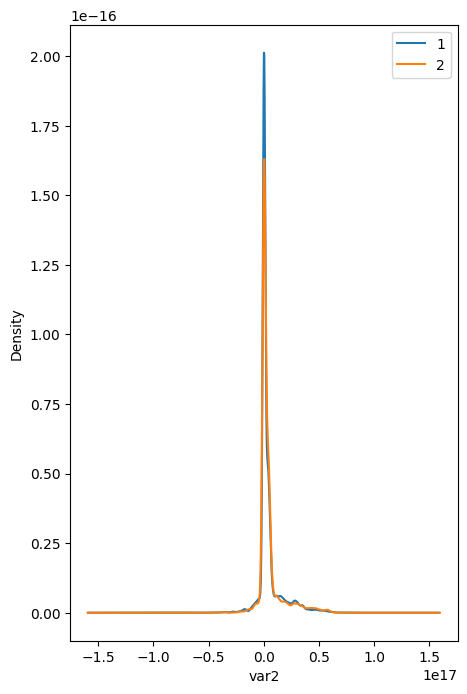

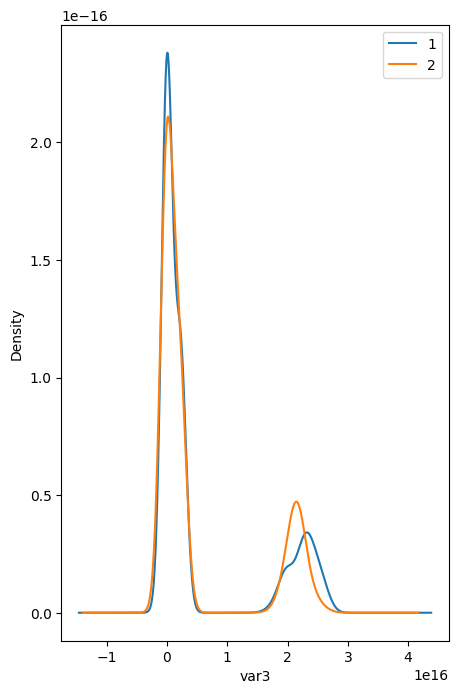

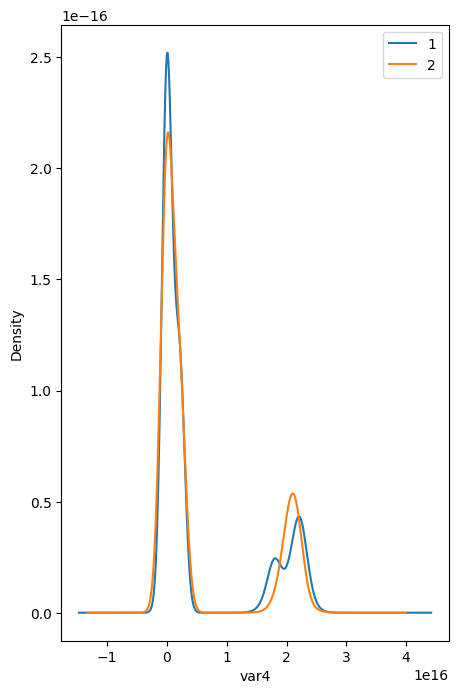

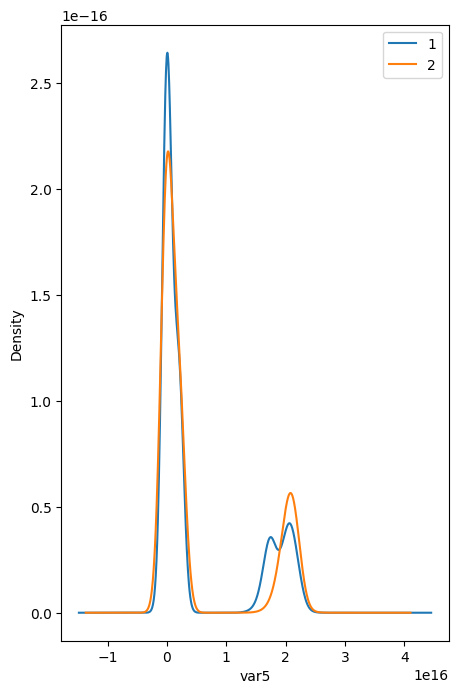

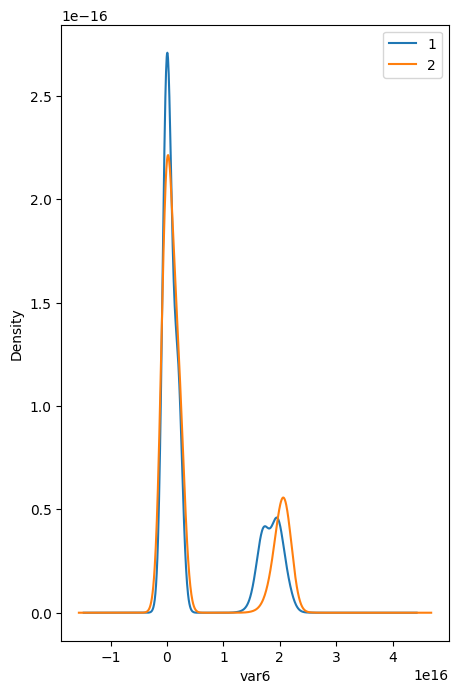

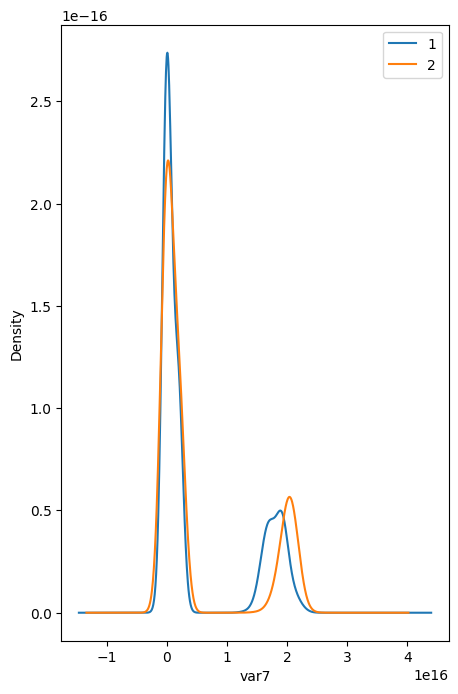

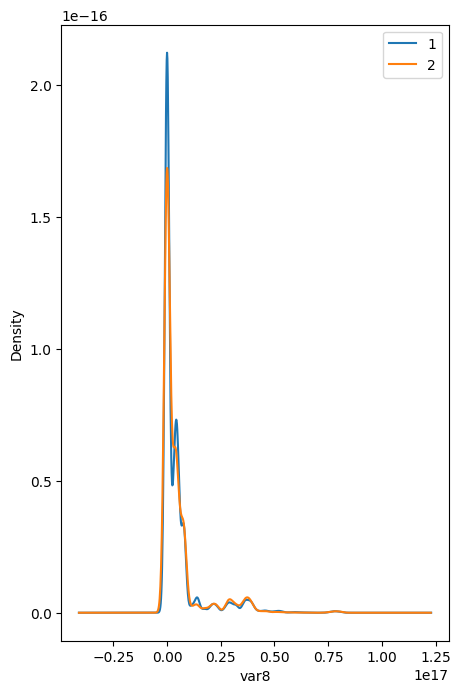

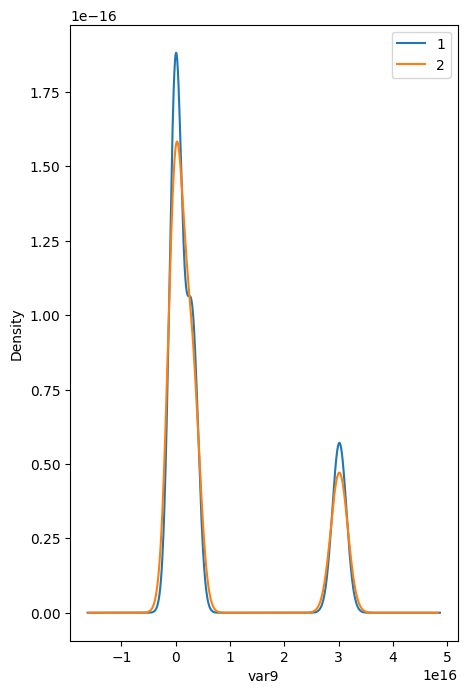

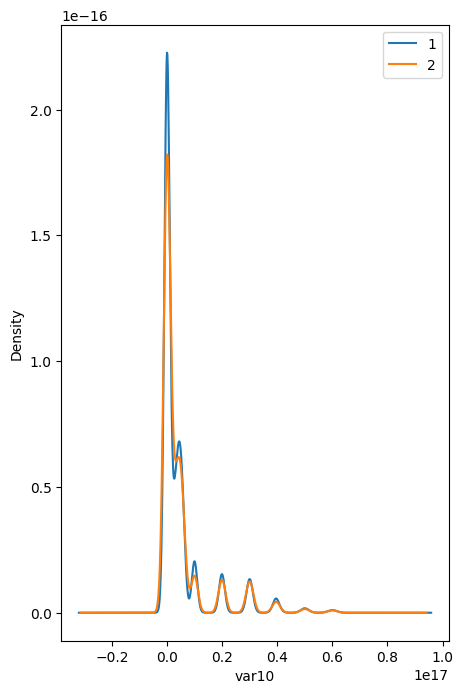

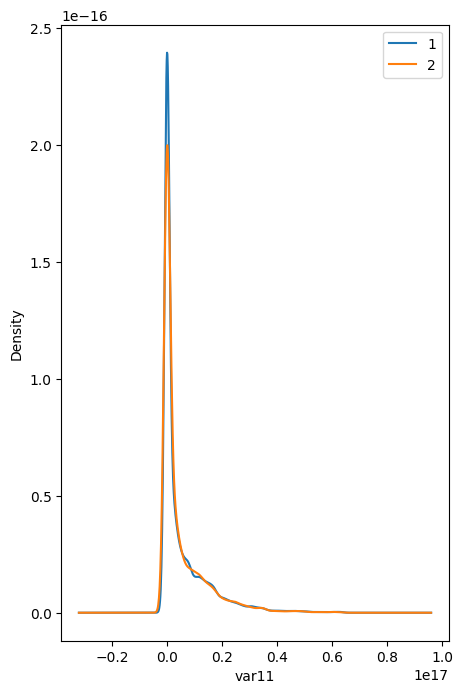

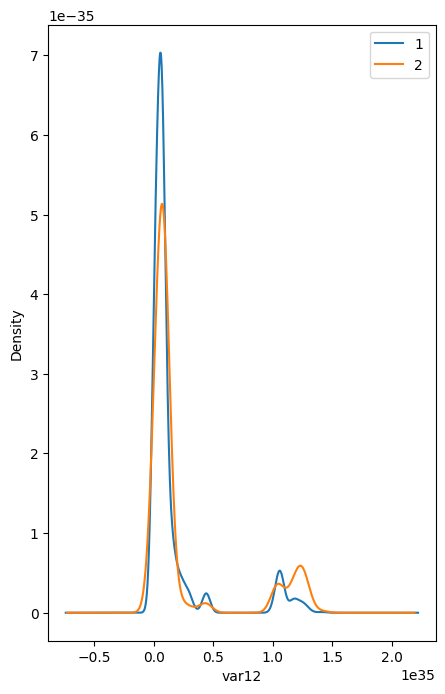

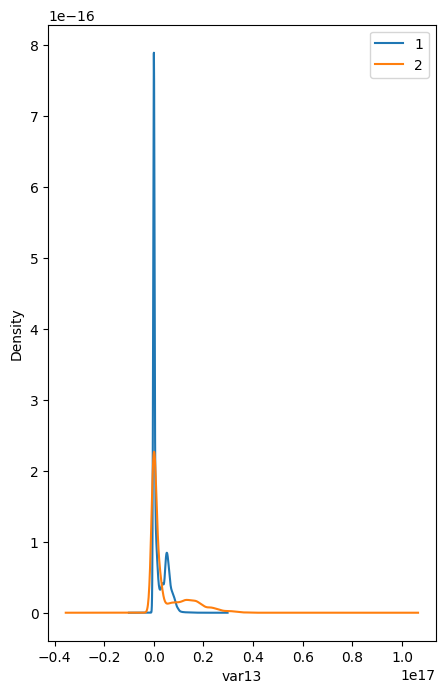

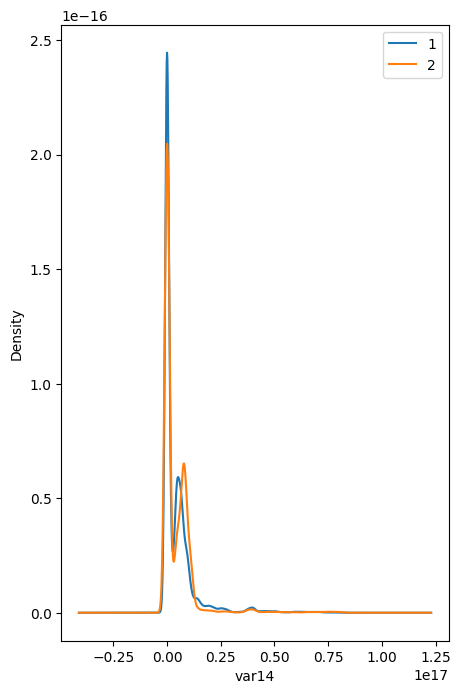

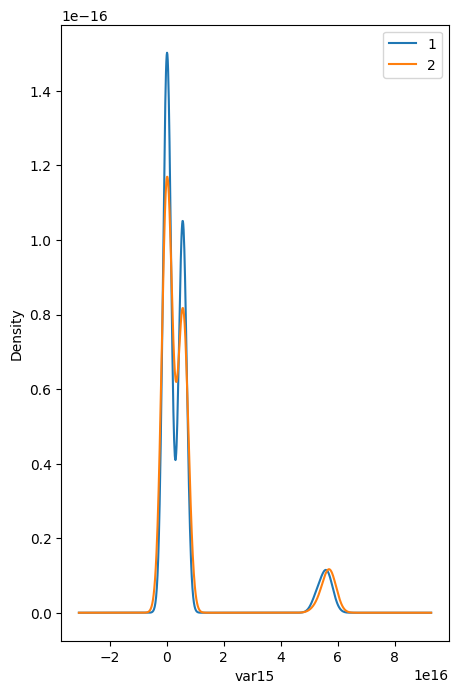

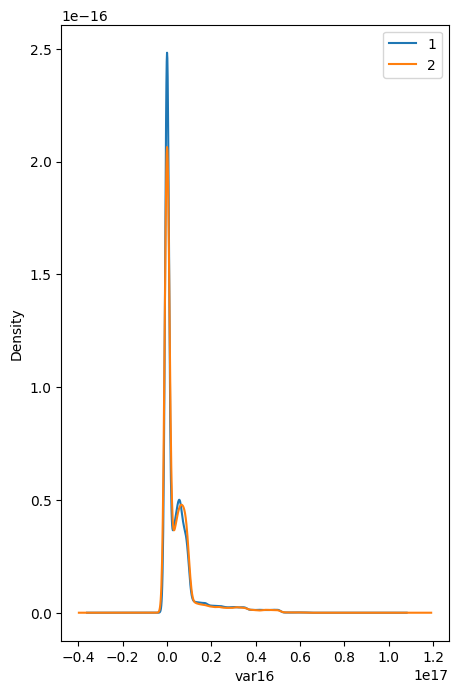

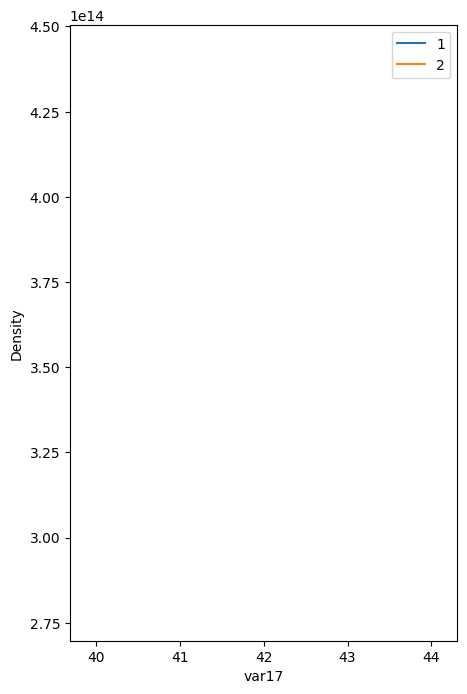

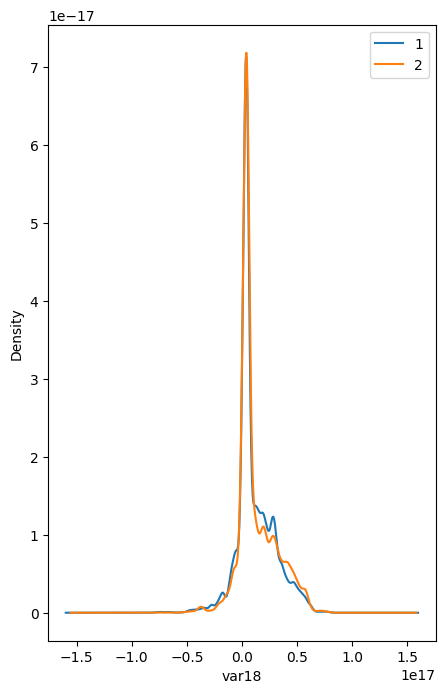

In [ ]:
for j in K: #creamos las gráficas de KDE (no me salieron las graficas en matriz, por eso las presento asi)
  DF.groupby("target")[j].plot(kind='kde',figsize=(5, 8)) #agrupamos por target y ploteamos la knd
  plt.legend([1, 2], loc='upper right') #ponemos las leyendas de las clases
  plt.xlabel(j)
  plt.show()




En genera, las distribuciones muestran una clara mezcla entre los datos, no estan separados como se pensó en los histogramas, si no que están mezclados en dos densidades separadas, lo que vuelve muy dificil el separar entre clases.

In [ ]:
DF.describe()

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,var10,var11,var12,var13,var14,var15,var16,var17,var18
count,125449.000000,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,1.254490e+05,125449.0,1.254490e+05
mean,1.241827,8.885202e+33,4.295026e+15,5.324964e+15,5.170204e+15,5.100153e+15,5.027717e+15,5.056874e+15,5.001271e+15,6.434824e+15,4.966586e+15,5.165507e+15,1.792366e+34,2.622766e+15,4.447392e+15,6.337466e+15,4.674603e+15,42.0,1.152133e+16
std,0.428192,5.228891e+33,1.065394e+16,8.931032e+15,8.461060e+15,8.137537e+15,7.933164e+15,7.866615e+15,1.015324e+16,1.136498e+16,9.720031e+15,8.978327e+15,3.230577e+34,4.665115e+15,8.762996e+15,1.433406e+16,8.588310e+15,0.0,1.703646e+16
min,1.000000,1.240000e+27,-7.971109e+16,1.579500e+01,1.444000e+01,1.288220e+01,1.212910e+01,1.198870e+01,1.090000e+02,3.010000e+02,1.000000e+00,1.100000e+01,2.290000e+27,-9.882397e+13,2.660000e+02,5.160800e+04,1.000000e+00,42.0,-7.992410e+16
25%,1.000000,1.240000e+33,2.045024e+14,2.210721e+06,2.112589e+06,2.009474e+06,1.935572e+06,1.894443e+06,4.192000e+03,3.010000e+02,4.000000e+00,1.480000e+02,4.320000e+33,3.701431e+06,5.303000e+03,5.601400e+04,4.460000e+02,42.0,2.772379e+15
50%,1.000000,1.240000e+34,5.069928e+14,2.356711e+12,2.402805e+12,2.132390e+12,2.144174e+12,2.029442e+12,4.636416e+12,3.072046e+12,4.899383e+12,9.133808e+12,6.890000e+33,9.811037e+06,6.434019e+12,5.594910e+12,6.123124e+12,42.0,5.396950e+15
75%,1.000000,1.240000e+34,4.311631e+15,2.479596e+15,2.308688e+15,2.225349e+15,2.199642e+15,2.300182e+15,5.002430e+15,3.053555e+15,4.987532e+15,7.017262e+15,1.030000e+34,4.313668e+15,6.426002e+15,5.616156e+15,6.214553e+15,42.0,2.059351e+16
max,2.000000,1.350000e+34,7.981410e+16,2.920761e+16,2.945897e+16,2.968032e+16,3.121816e+16,2.931094e+16,8.190610e+16,3.240475e+16,6.390629e+16,6.397448e+16,1.480000e+35,7.097757e+16,8.190374e+16,6.190878e+16,7.939220e+16,42.0,7.994423e+16


De la estadística descriptiva, podemos decir que tenemos datos con ordenes de magnitud gigantes. Hay columnas con valores mínimos negativos, y otros con valores mínimos con diferencias de mas de x10^10, por lo que es posible que sean outliers, además muchas desviaciones estándar son del mismo orden de magnitud que el promedio, no se ven del todo bien, los terminos masivos dominan por completo las medidas estadisticas.

Boxplots

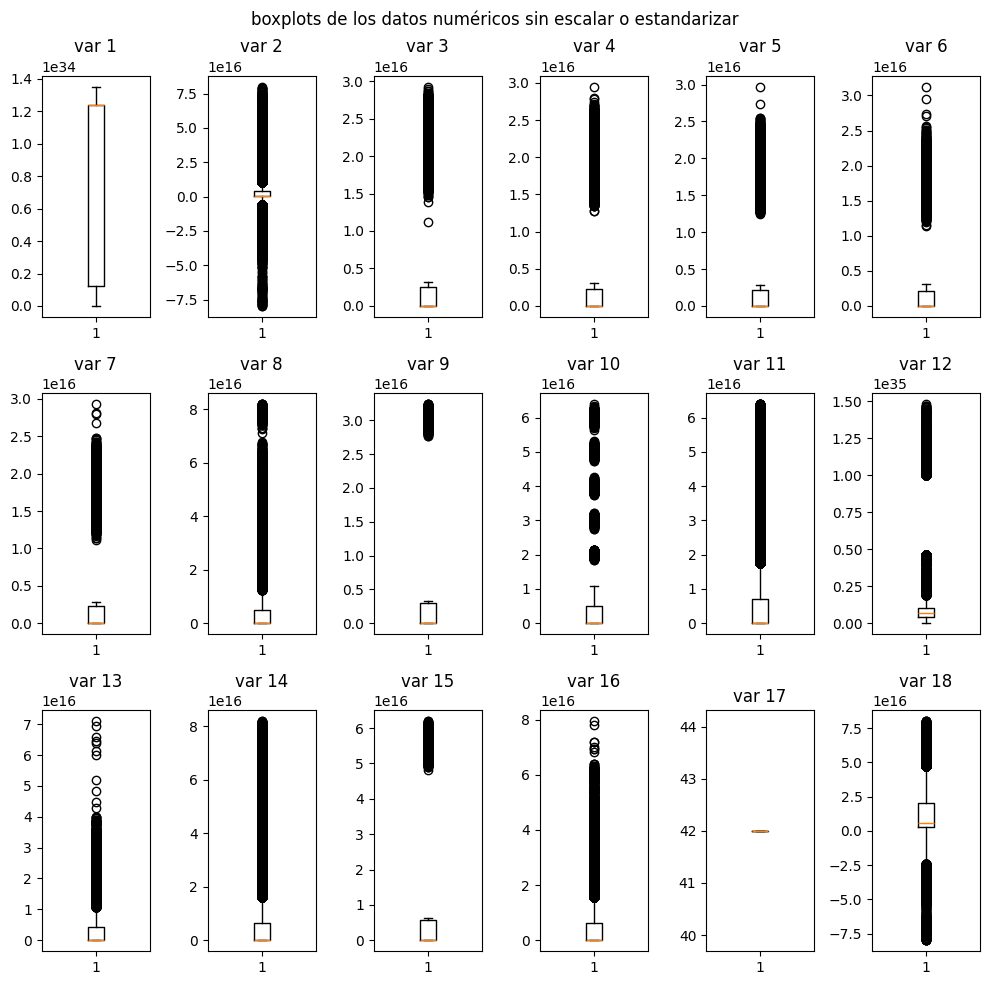

In [ ]:
#aplicaremos un boxplot y  violin plot, para buscar outliers

import seaborn as sns
import matplotlib.pyplot as plt

#creamos un conjunto de figuras
fig,axes=plt.subplots(3, 6, figsize=(10, 10)) #para hacer 18 gráficas de boxplots de 5x8
axes=axes.flatten()
fig.suptitle("boxplots de los datos numéricos sin escalar o estandarizar")
KK=[DF[f"var{i}"] for i in range(1,19,1)]

for i, datos in enumerate(KK):
    axes[i].boxplot(datos)
    axes[i].set_title(f'var {i+1}')

plt.tight_layout()
plt.show()


Podemos apreciar que casi todos los valores en casi todos los diagramas de boxplot se salen de la caja (y de los bigotes), lejos de los bigotes, están muy alejados de la parte central de la caja, en parte debido a sus ordenes de magnitud, por lo que ahora lo que queremos hacer es bajarselos con logaritmos, es posible que tengamos problemas con los valores negativos de los datos, pero puede bastar que bajemos el orden de magnitud y después multipliquemos por un menos para que siga siendo negativo.
Por otro lado, la mayoria de los datos en las distintas var superan el percentil del 75 %, por lo que los datos decimales on ínfimos a comparación de los de órdenes de magnitud de E+17, aunque algunas variables tienen dos distribuciones mas o menos uniformes (var18 y var2).

Ahora con un violin plot

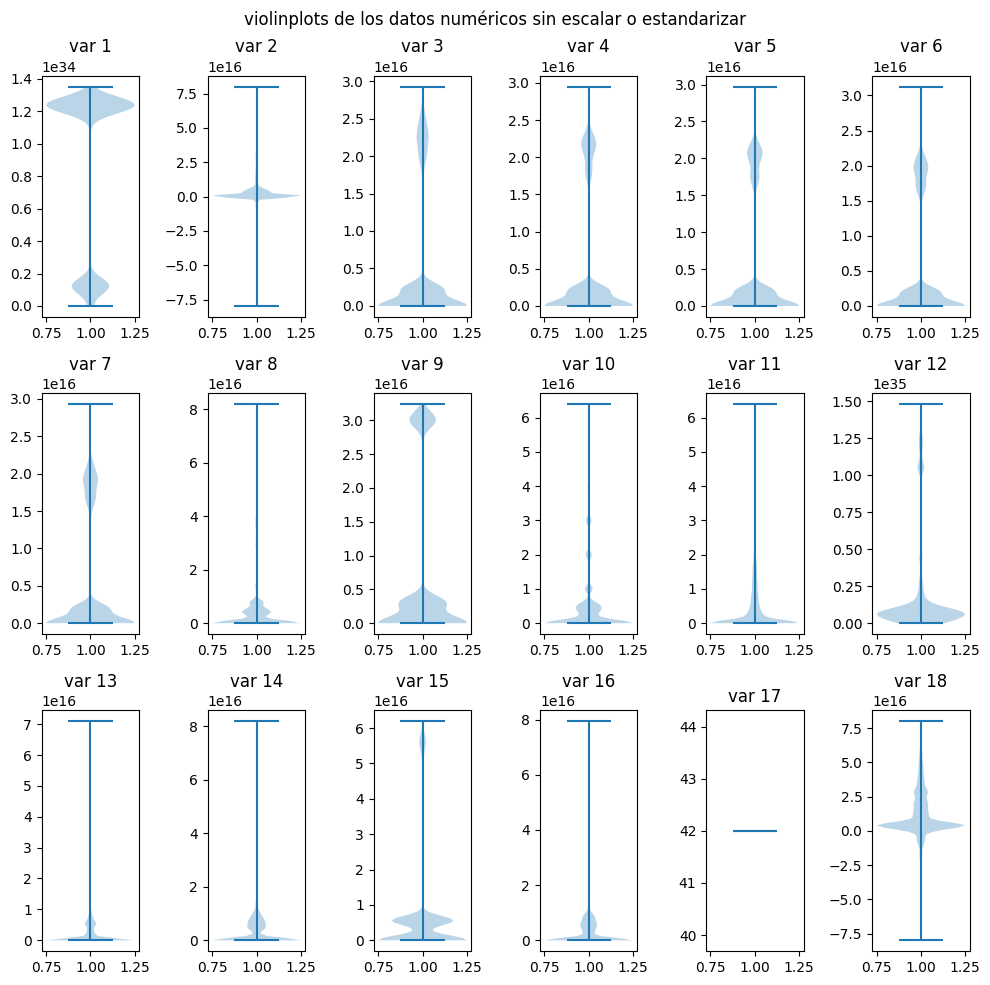

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#creamos un conjunto de figuras
fig,axes=plt.subplots(3, 6, figsize=(10, 10)) #para hacer 18 gráficas de boxplots de 3x6
fig.suptitle("violinplots de los datos numéricos sin escalar o estandarizar")
axes=axes.flatten()
KK=[DF[f"var{i}"] for i in range(1,19,1)] #nuevamente nuestra lista de nombres de columnas

for i, datos in enumerate(KK):
    axes[i].violinplot(datos) #ploteamos los datos apartir de su respectiva columna
    axes[i].set_title(f'var {i+1}')

plt.tight_layout()
plt.show()




El violin plot nos muestra la KDE de las variables, hay zonas mas angostas que otras, y la mayoria concentra una mayor densidad en el cero y hay algunos puntos con órdenes de magnitud gigantes que me estiran el violin en dos partes, por lo que ratifico mi desición de bajar los órdenes de magnitud de los datos.

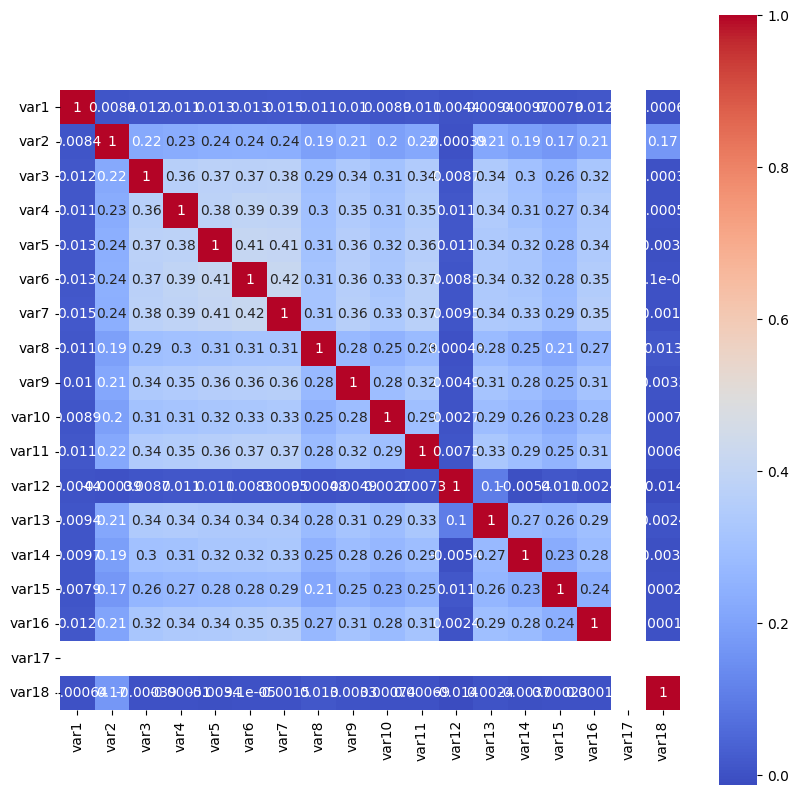

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(DF.iloc[:, 1:19].corr(), annot=True, square=True, cmap='coolwarm')#armamos la matriz de correlaciones de todas las variables
plt.show()

La mayor parte de las variables tienen muy poca correlación (por pearson), sin embargo estos valores se repiten mucho, casi todos entre 0.25 y 0.35. Por otro lado, la var17 no aporta información útil con ninguna variable

Vamos a bajar los órdenes de magnitud de los datos, de modo que buscaremos que los que sean negativos se queden negativos

In [ ]:
DF.shape

(125449, 19)

Vamos a aplicar el logaritmo a todos nuestros datos, van a aparecer mas valores en cero puesto que log(1)=0, pero todos bajarán sus órdenes de magnitud

In [8]:
K=[f"var{i}" for i in range(1,19,1)] #esta lista es para generar el nombre de las columnas

for j in K: #iteramos sobre cada columna
  k1=DF[j]==0 # si el valor es cero
  k2=DF[j]<0 #si el valor es negativo

  kk=[k1,k2] #metemos las condiciones dentro de la lista de condiciones
  por_defecto=np.log(DF[j]) #si es positivo, que le aplique el logaritmo
  r1=0 #caso de que sea cero
  r2=-1*np.log(np.abs(DF[j])) #si se encuentra un negativo
  RR1=[r1,r2]

  DF.loc[:,j]=np.select(kk,RR1,default=por_defecto)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_87621/3261006047.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 35.64868288  33.50412267  32.54108956 ... -37.4560508   37.11762521
  35.22504631]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  DF.loc[:,j]=np.select(kk,RR1,default=por_defecto)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_87621/3261006047.py:13: FutureWarning: Setting an item of incompatible dtype is deprec

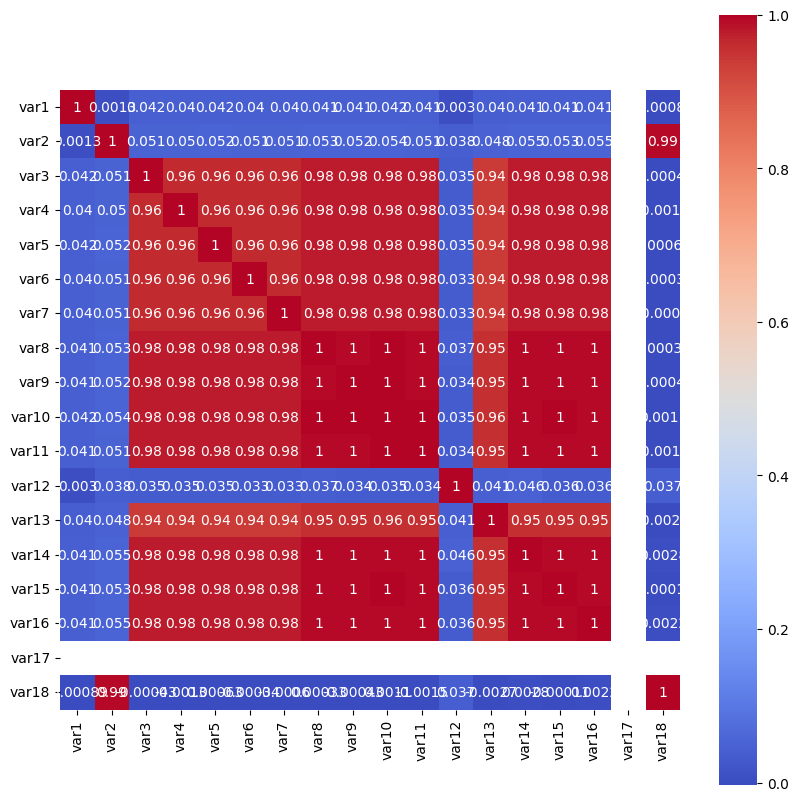

In [9]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(DF.iloc[:, 1:19].corr(), annot=True, square=True, cmap='coolwarm')#sacamos las correlaciones después de aplicar logaritmo y dejar los negativos como negativos y los 1 como ceros
plt.show()

Ahora observamos alta correlación entre las variables centrales, después de aplicar un logaritmo a todos los datos, por lo que muchas de ellas presentan comportamientos de hasta 1, o 0.98 lo que las hace variables hermanas, sospechamos que podemos deshacernos de algunas de esas columnas puesto que transmiten información similar, también pensamos que dado que las variables var12,var18, var1 y var2 no estan muy correlacionadas, podriamos eliminarlas.
Por otra parte, dado que hay muchas columnas con alta correlación aplicaremos PCA para reducir la dimensionalidad

In [ ]:
(DF<0).sum().sum() #contamos cuantos negativos tenemos ahora (se agrego 1 mas por que habia un valor entre 0 y 1 que el logaritmo clasifico como negativo)

np.int64(29019)

In [ ]:
(DF>0).sum().sum() #cuantos posiitivos

np.int64(2345363)

In [ ]:
(DF==0).sum() #aparecieron 8442+54 nuevos ceros que antes eran 1 en el dataframe anterior

,0
target,0
var1,0
var2,0
var3,0
var4,0
var5,0
var6,0
var7,0
var8,0
var9,0


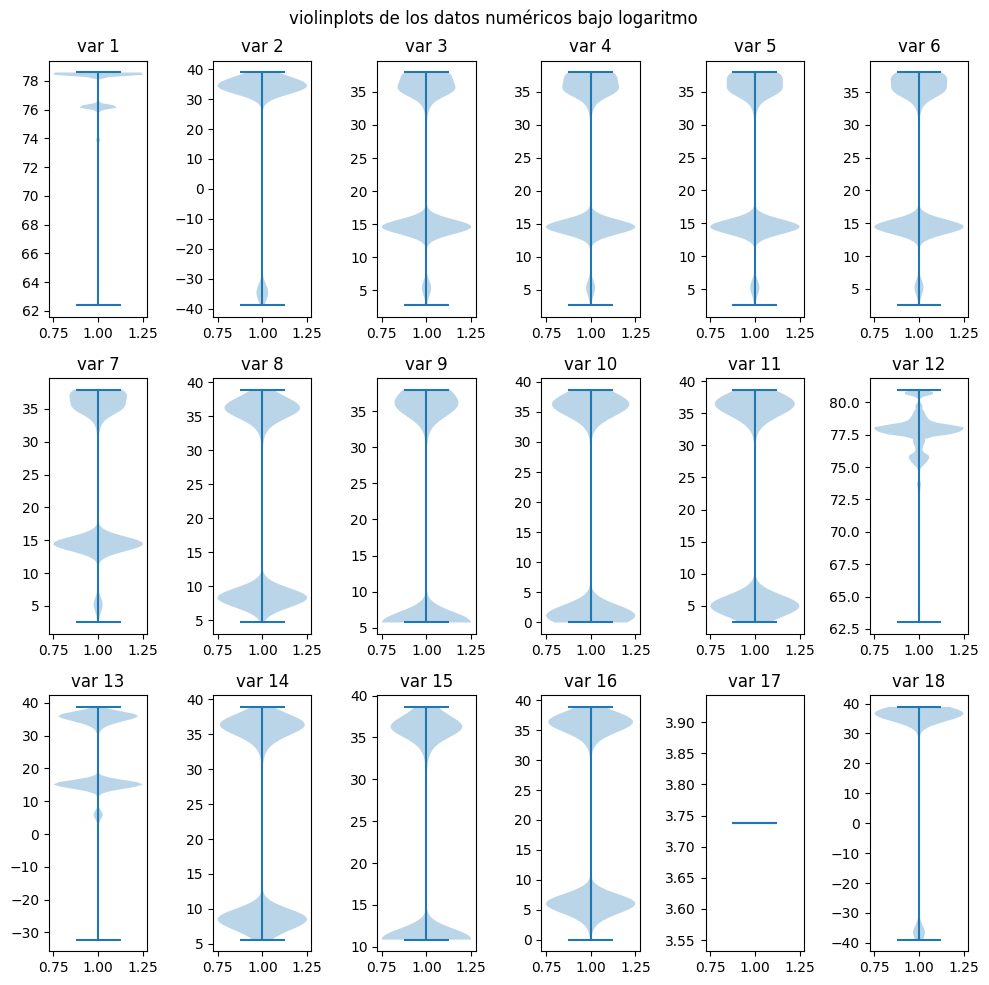

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#volvemos a hacer los violinplots pero con los datos escalados por el logaritmo
fig,axes=plt.subplots(3, 6, figsize=(10, 10)) #para hacer 18 gráficas de boxplots de 3x6
fig.suptitle("violinplots de los datos numéricos bajo logaritmo")
axes=axes.flatten()
KK=[DF[f"var{i}"] for i in range(1,19,1)]

for i, datos in enumerate(KK):
    axes[i].violinplot(datos)
    axes[i].set_title(f'var {i+1}')

plt.tight_layout()
plt.show()


De los violin plot, muchas densidades se separaron del cero respecto al anterior grafico de violin, ahora se nota una mayoria de datos lejos del cero, sin embargo sigue el desbalance de clases y una mezcla de clases importante.

Por otra parte, de las matrices de correlación, vimos que hay muchas variables fuertemente correlacionadas, por lo que podríamos quitar algunas variables puesto que representan la misma información, para ello aplicaremos el análisis de componentes principales. Por otra parte, la var17 no representa ninguna correlación y de hecho es el mismo valor para todos los registros, por lo que la eliminaremos apartir de ahora.

A continuación, definimos nuestro conjunto de entrenamiento que usaremos para los modelos.

In [10]:
X=DF.drop(columns=["target","var17"]) #quitamos la var17 para entrenar
y=DF["target"] #nos quedamos con los targets


Aplicamos PCA para encontrar el mejor número de componentes principales

In [ ]:
#primero estandarizamos
X_mean = X.mean()
X_std = X.std()
Z = (X - X_mean) / X_std

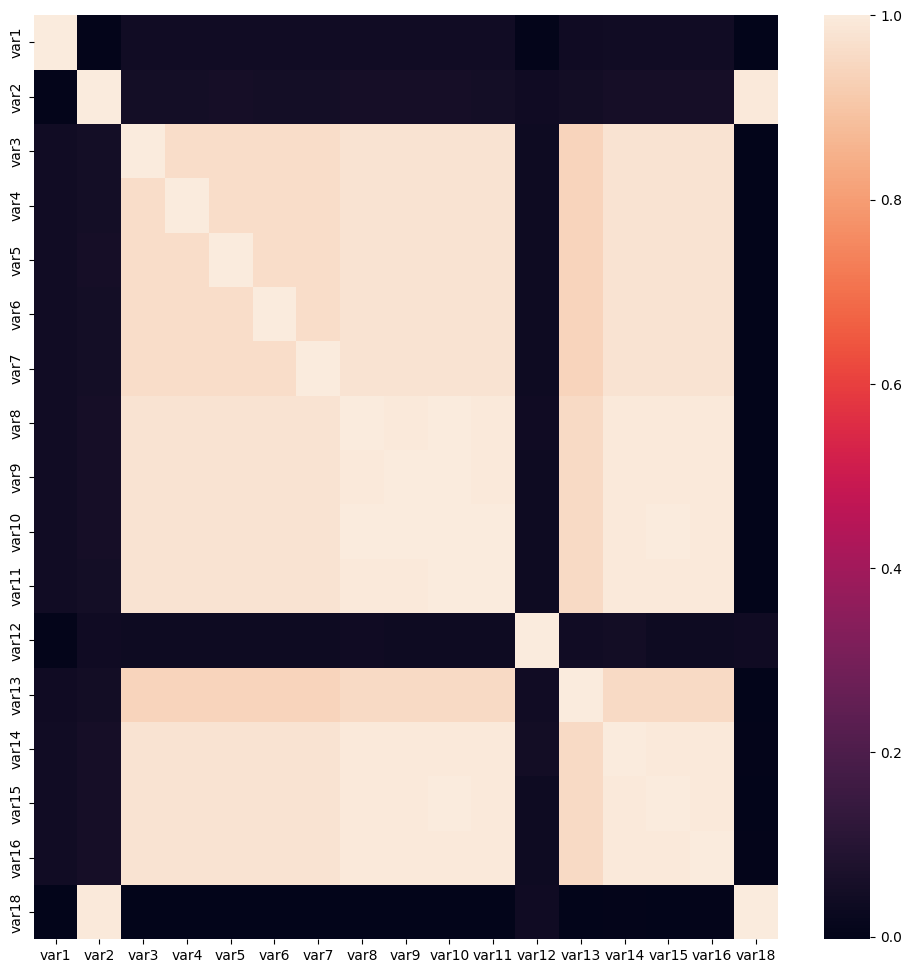

In [ ]:
c = Z.cov() #calculamos la matriz de covarianza
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 12))
sns.heatmap(c) #vemos el mapa de calor
plt.show()

Es muy similar a la de correlaciones, por lo que nuevamente detectamos alta correlación y covarianza para las varriables desde la 4 hasta la 10, y 13,14 y 15.

In [ ]:
import numpy as np
eigenvalues, eigenvectors = np.linalg.eig(c) #calculamos valores y vectores propios
print('Valores propios:\n', eigenvalues)
print('Forma de los valores propios:', eigenvalues.shape)
print('Forma de los vectores propios:', eigenvectors.shape)

Valores propios:
 [1.27239317e+01 1.99585529e+00 9.98824771e-01 9.95340472e-01
 8.01466543e-02 2.38998644e-02 3.87634035e-02 3.75102541e-02
 3.79940980e-02 3.78013442e-02 3.29129291e-03 3.78761837e-03
 4.97539787e-03 4.22045393e-03 4.37059014e-03 4.52294473e-03
 4.76387087e-03]
Forma de los valores propios: (17,)
Forma de los vectores propios: (17, 17)


In [ ]:
idx = eigenvalues.argsort()[::-1] #crea una lista de índices de mayor a menor
eigenvalues = eigenvalues[idx] #ordena los eigenvalores de mayor a menor
eigenvectors = eigenvectors[:, idx] #al igual que los eigenvectores

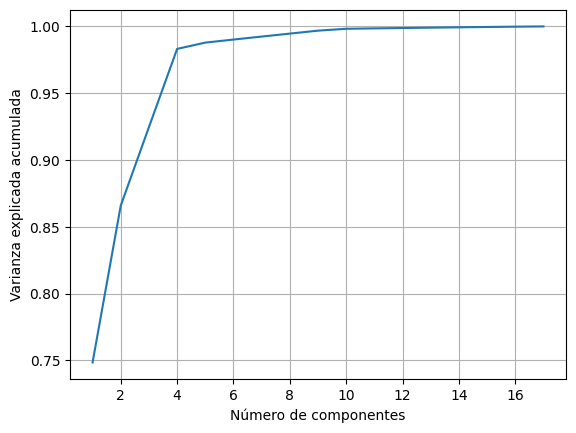

In [ ]:
explained_var = np.cumsum(eigenvalues) / np.sum(eigenvalues) #calcula la varianza explicada acumulada
plt.plot(range(1, len(explained_var) + 1), explained_var) #la graficamos contra el número de componentes principales
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.grid()
plt.show()

La varianza explicada acumulada nos dice que con 4 componentes principales podemos conservar mas del 95 % de la varianza explicada acumulada, y apartir de 8 para tener valores cercanos al 100 %.

Visualizamos en un espacio 2D las componentes principales. En todos los casos, no hay una separación clara, se ven como agrupamientos mezclados de ambas clases, no hay forma de separarlos a menos que sean fronteras muy raras y extravagantes.

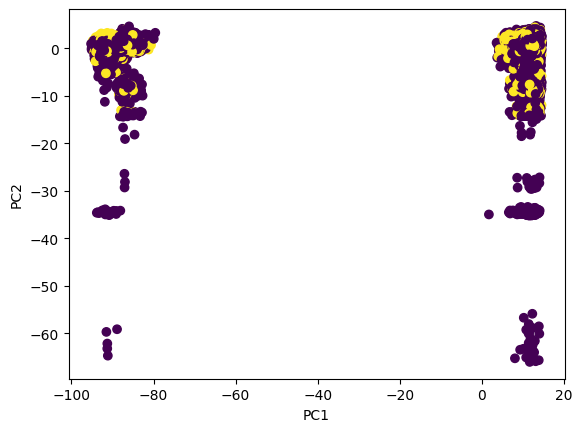

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4) # con 4 componentes
X_pca1 = pca.fit_transform(X)

plt.scatter(X_pca1[:, 1], X_pca1[:, 2], c=y) #ploteamos la componente 1 y 2
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Entrenamos un random forest con k-fold a ver que pasa

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold #importamos las librerias necesarias
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler

#Este código viene de la clase 11 del curso
#dividimos en conjunto de prueba y validación, usaremos un for posteriormente para realizar las evaluaciones
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234) #usamos el kfold estratificado para mantener la proporción entre las clases

accuracies = [] #aqui metemos las precisiones de cada fold
sizes = [] #aqui metemos los tamaños de los pesos que usaremos para ponderar posteriormente


fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid):# aqui mi for me parte en 5 cachos los indices de los datos de entrenamiento y validación para realizar los k-folds
  print(f"\n--- Fold {fold_num}---") #me avisa en que fold va
  #va buscando los datos cuyos indices ya partió el for y me los ponen en mis datos de entrenamiento y validación
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]


  rf = RandomForestClassifier(n_estimators=150, random_state=123) #importamos el randomforest

  scaler = MinMaxScaler() #aplicamos minMaxScaler para los árboles (para probar)
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir
  rf.fit(X_train_scaled, y_train)




  acc = accuracy_score(y_valid, rf.predict(X_test_scaled)) #importamos las métricas
  print(classification_report(y_valid, rf.predict(X_test_scaled))) #importamos el reporte de clasificación
  accuracies.append(acc) #pegamos las accuracies
  sizes.append(len(y_valid)) #pegamos el tamaño de los pesos basandonos en el tamaño de mis etiquetas de prueba
  fold_num += 1 #sigue el siguiente fold
weighted_avg_acc = np.average(accuracies, weights=sizes) #vemos cual es la presición ponderada
print("\nPrecisiones por fold:", accuracies) #imprimimos
print("Tama~nos por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))











--- Fold 1---
              precision    recall  f1-score   support

           1       0.95      0.98      0.96     15218
           2       0.91      0.83      0.87      4854

    accuracy                           0.94     20072
   macro avg       0.93      0.90      0.91     20072
weighted avg       0.94      0.94      0.94     20072


--- Fold 2---
              precision    recall  f1-score   support

           1       0.95      0.97      0.96     15218
           2       0.91      0.83      0.86      4854

    accuracy                           0.94     20072
   macro avg       0.93      0.90      0.91     20072
weighted avg       0.94      0.94      0.94     20072


--- Fold 3---
              precision    recall  f1-score   support

           1       0.95      0.97      0.96     15218
           2       0.90      0.83      0.87      4854

    accuracy                           0.94     20072
   macro avg       0.93      0.90      0.91     20072
weighted avg       0.94      

Clasifica muy bien la clase mayoritaria, pero falla en la clase minoritaria, se debe en parte al desbalance de clases que se tiene, pensamos que una posible causa sea el desbalance de las clases.

Modelo para guardar

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,shuffle=True)

#skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

SScaler = MinMaxScaler()
X_train_scaled = SScaler.fit_transform(X_train) #entrenaremos con estos datos escalados
X_test_scaled = SScaler.transform(X_test) #los usaremos para predecir

RF = RandomForestClassifier(n_estimators=150, random_state=123)

RF.fit(X_train_scaled, y_train)

y_pred = RF.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

import joblib
joblib.dump(RF, "modelo_randomForest.pkl")
joblib.dump(SScaler, "modelo_scalador.pkl")

              precision    recall  f1-score   support

           1       0.95      0.97      0.96     19023
           2       0.91      0.85      0.88      6067

    accuracy                           0.94     25090
   macro avg       0.93      0.91      0.92     25090
weighted avg       0.94      0.94      0.94     25090

[[18501   522]
 [  935  5132]]


['modelo_scalador.pkl']

Ahora un árbol de desición

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import KFold
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
X_test_scaled = scaler.transform(X_test) #los usaremos para predecir

clf = DecisionTreeClassifier()

clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.94      0.94      0.94     19023
           2       0.81      0.82      0.81      6067

    accuracy                           0.91     25090
   macro avg       0.87      0.88      0.88     25090
weighted avg       0.91      0.91      0.91     25090

[[17854  1169]
 [ 1118  4949]]


Árbol de desición con kfolds

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
#este codigo y los restantes se basan en el primer codigo de k-folds y esta basado en el codigo de la clase 11 el curso
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,shuffle=True)

#volvemos a hacer lo anterior
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

accuracies = []
sizes = []


fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid): #volvemos a partir los indices de los datos
  print(f"\n--- Fold {fold_num}---")
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]


  clf = DecisionTreeClassifier() #importamos el desiciontree

  scaler = MinMaxScaler()
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir
  clf.fit(X_train_scaled, y_train)

  #volvemos a imprimir las métricas
  acc = accuracy_score(y_valid, clf.predict(X_test_scaled))
  print(classification_report(y_valid, clf.predict(X_test_scaled)))
  accuracies.append(acc)
  sizes.append(len(y_valid))
  fold_num += 1
weighted_avg_acc = np.average(accuracies, weights=sizes)
print("\nPrecisiones por fold:", accuracies)
print("Tama~nos por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))


--- Fold 1---
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     15218
           2       0.80      0.80      0.80      4854

    accuracy                           0.90     20072
   macro avg       0.87      0.87      0.87     20072
weighted avg       0.90      0.90      0.90     20072


--- Fold 2---
              precision    recall  f1-score   support

           1       0.94      0.93      0.94     15218
           2       0.79      0.80      0.80      4854

    accuracy                           0.90     20072
   macro avg       0.87      0.87      0.87     20072
weighted avg       0.90      0.90      0.90     20072


--- Fold 3---
              precision    recall  f1-score   support

           1       0.94      0.94      0.94     15218
           2       0.80      0.81      0.81      4854

    accuracy                           0.91     20072
   macro avg       0.87      0.87      0.87     20072
weighted avg       0.91      

Sus métricas para clasificar datos con la clase 2 son peores que con el random forest, lo que es esperable dado que es un solo árbol

Ahora entrenaremos un random forest con PCA

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.decomposition import PCA
#misma técnica
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

accuracies = []
sizes = []



fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid):
  print(f"\n--- Fold {fold_num}---")
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]


  clf1 = RandomForestClassifier()

  scaler = StandardScaler() #escalamos antes de meterlo a PCA
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir

  pca = PCA(n_components=10, random_state=42) #invocamos PCA con 10 componentes (mas de 95% de varianza explicada acumulada)
  X_train_pca = pca.fit_transform(X_train_scaled) # preparamos con fit_transform() los datos escalados
  X_valid_pca = pca.transform(X_test_scaled)


  clf1.fit(X_train_pca, y_train) #entrenamos

#calculamos las métricas
  yp=clf1.predict(X_valid_pca)
  acc = accuracy_score(y_valid, yp)
  print(classification_report(y_valid, yp))
  accuracies.append(acc)
  sizes.append(len(y_valid))
  fold_num += 1
weighted_avg_acc = np.average(accuracies, weights=sizes)
print("\nPrecisiones por fold:", accuracies)
print("Tama~nos por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))


--- Fold 1---
              precision    recall  f1-score   support

           1       0.91      0.98      0.94     15218
           2       0.91      0.71      0.79      4854

    accuracy                           0.91     20072
   macro avg       0.91      0.84      0.87     20072
weighted avg       0.91      0.91      0.91     20072


--- Fold 2---
              precision    recall  f1-score   support

           1       0.92      0.97      0.94     15218
           2       0.90      0.72      0.80      4854

    accuracy                           0.91     20072
   macro avg       0.91      0.85      0.87     20072
weighted avg       0.91      0.91      0.91     20072


--- Fold 3---
              precision    recall  f1-score   support

           1       0.92      0.97      0.95     15218
           2       0.90      0.74      0.81      4854

    accuracy                           0.92     20072
   macro avg       0.91      0.86      0.88     20072
weighted avg       0.92      

Las métricas resultan peor aun para la clase minoritaria que con el random forest, al menos con 10 componentes, pensamos que se debe a que domina la clase mayoritaria incluso al disminuir la dimensionalidad.

Red neuronal MLP


--- Fold 1---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


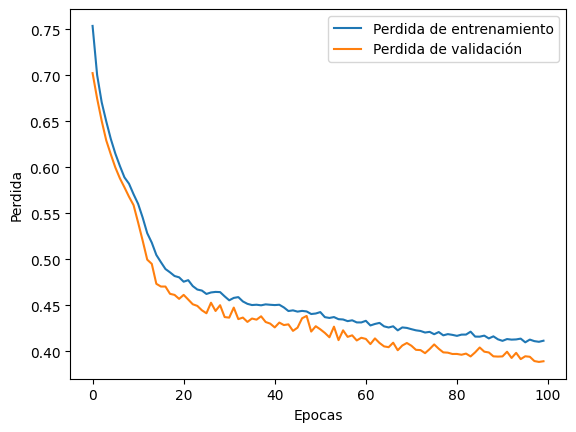

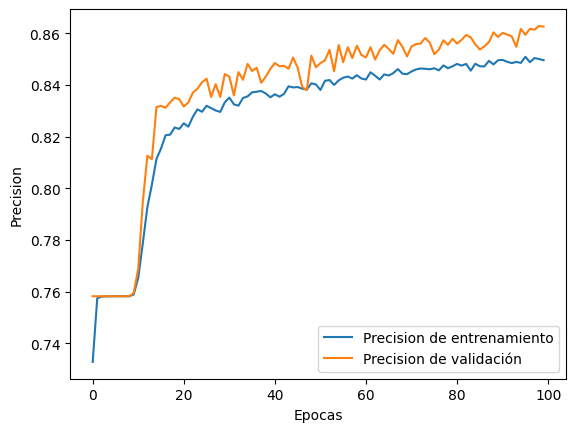

Loss: 0.38901156187057495
Accuracy: 0.8625946640968323

--- Fold 2---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


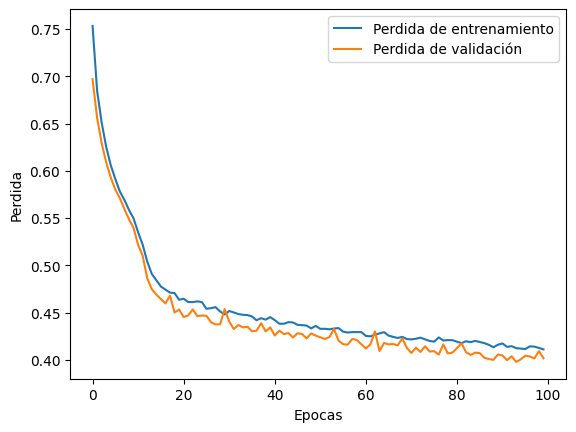

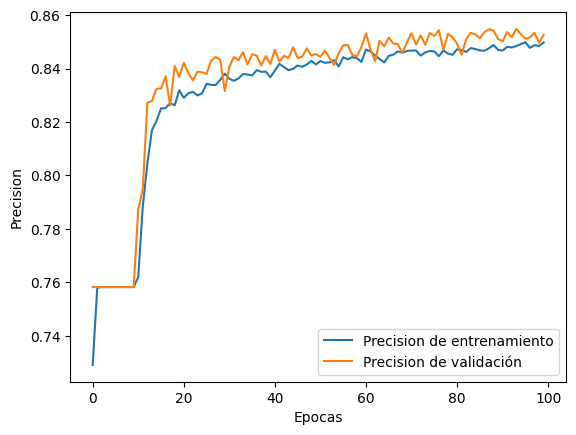

Loss: 0.4017040729522705
Accuracy: 0.8526305556297302

--- Fold 3---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


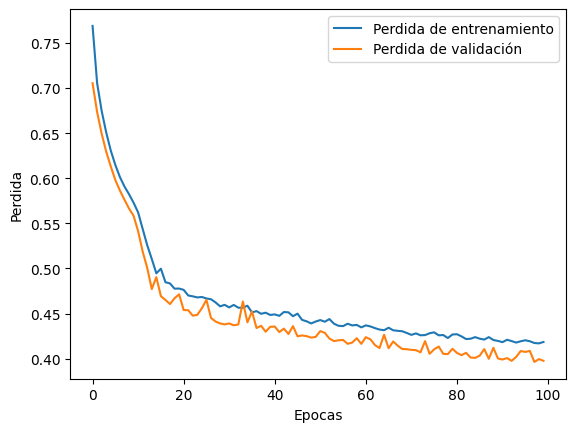

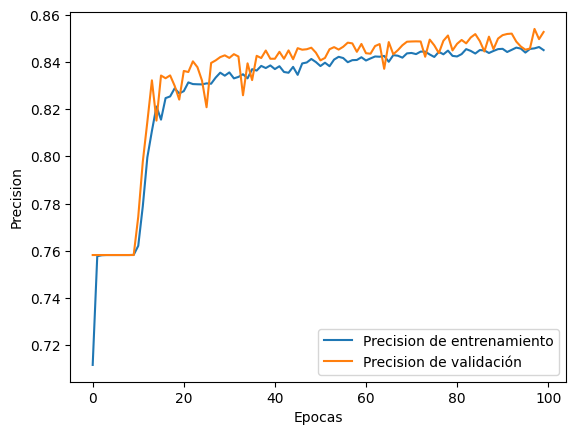

Loss: 0.39762893319129944
Accuracy: 0.8528298139572144

--- Fold 4---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


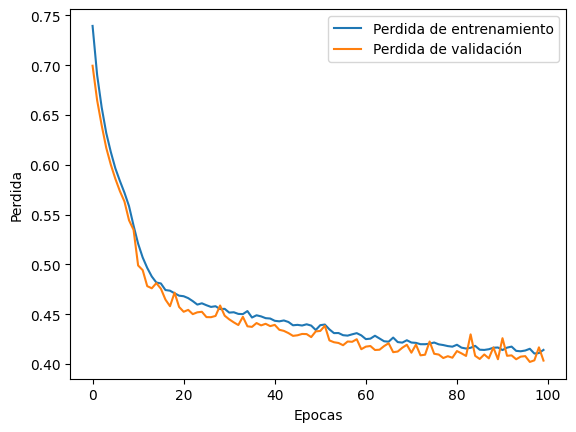

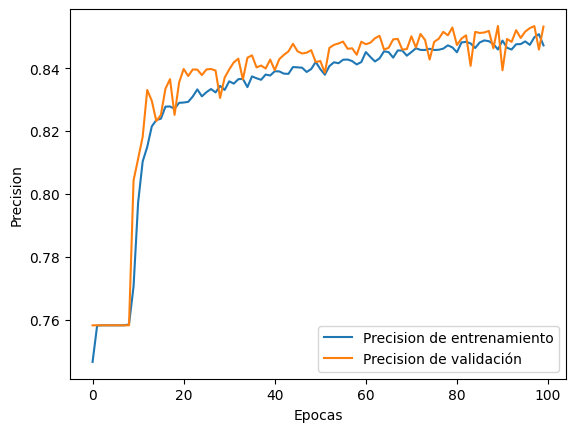

Loss: 0.40352681279182434
Accuracy: 0.8532283902168274

--- Fold 5---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


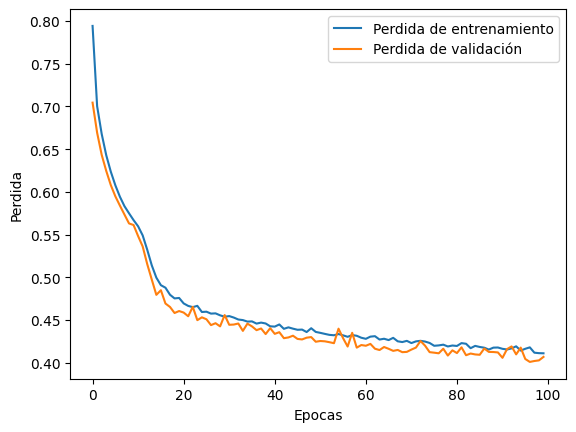

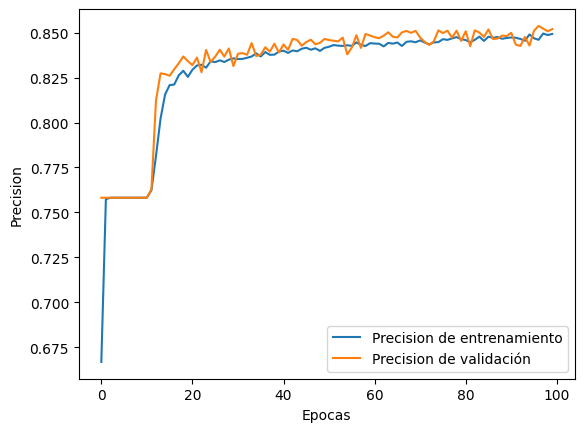

Loss: 0.4068407714366913
Accuracy: 0.8519755005836487

Precisiones por fold: [0.8625946640968323, 0.8526305556297302, 0.8528298139572144, 0.8532283902168274, 0.8519755005836487]
Tamañnos por fold: [20072, 20072, 20072, 20072, 20071]
Precisión promedio ponderada: 0.8546518115639588
Precisión promedio simple: 0.8546517848968506


In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold #importamos las métricas anteriores mas las de keras para graficas las curvas de validación y perdida
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout #importamos los modelos de regulación para sacar el máximo provecho a la neurona
from tensorflow.keras.regularizers import l2
import numpy as np
#partimos el conjunto de datos
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234) #invocamos kfold

accuracies = []
sizes = []



fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid):
  print(f"\n--- Fold {fold_num}---")
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]



  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir

#aplicamos la disminuación de 1 en los targets dado que cros_entropy detectara los targets 0,1 y 2, añadiendo uno extra, por lo que disfrasamos los targets con 0 y 1
  y_trainv=y_train-1
  y_testv=y_valid-1

  y_train_cat = to_categorical(y_trainv, 2) #pasamos a expresiones categoricas de vectores columna en las clases
  y_test_cat = to_categorical(y_testv, 2)

#Creamos la arquitectura de la red neuronal, esta configuración de parámetros resulto de muchos intentos sin exito
  model = Sequential()

  model.add(Dense(128, activation='relu',kernel_regularizer=l2(0.001),input_shape=(17,)))

  model.add(Dropout(0.15))
  model.add(Dense(64, activation='relu',kernel_regularizer=l2(0.001)))

  model.add(Dropout(0.10))
  model.add(Dense(32, activation='relu',kernel_regularizer=l2(0.001)))

  model.add(Dropout(0.10))
  model.add(Dense(16, activation='relu',kernel_regularizer=l2(0.001)))

  model.add(Dropout(0.15))
  model.add(Dense(2, activation='softmax')) # 2 clases
# Compilar el modelo
  model.compile(loss='categorical_crossentropy',
            optimizer="adam",
              metrics=['accuracy'])
#añadimos un bacht_size de mas de 2000 para aprovechar la funcionalidad del GPU en el compilado de esta red
  history=model.fit(X_train_scaled, y_train_cat,validation_data=(X_test_scaled, y_test_cat), epochs=100,batch_size=2048,verbose=0)

#graficamos las pérdidas y precisiones

  plt.plot(history.history['loss'], label='Perdida de entrenamiento')
  plt.plot(history.history['val_loss'], label='Perdida de validación')
  plt.xlabel('Epocas')
  plt.ylabel('Perdida')
  plt.legend()
  plt.show()

  plt.plot(history.history['accuracy'], label='Precision de entrenamiento')
  plt.plot(history.history['val_accuracy'], label='Precision de validación')
  plt.ylabel('Precision')
  plt.xlabel('Epocas')
  plt.legend()
  plt.show()
#evaluamos el modelo
  loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
  print("Loss:", loss)
  print("Accuracy:", accuracy)
#calculamos las métricas
  accuracies.append(accuracy)
  sizes.append(len(y_valid))
  fold_num += 1
weighted_avg_acc = np.average(accuracies, weights=sizes)
print("\nPrecisiones por fold:", accuracies)
print("Tamañnos por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))




Las gráficas no presentan sobreajuste, sin embargo oscilan violentamente en la mayor parte de su evolución tanto en las pérdidas como en la validación, no tenemos una causa sensata de esto, pero se sospecha de los parámetros de dropout y L2.

Modelo para guardar de red neuronal

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


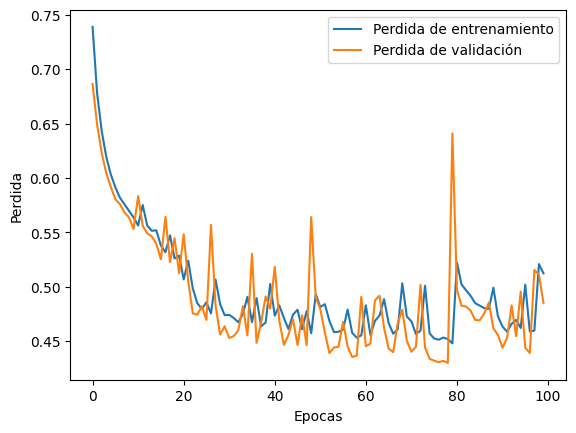

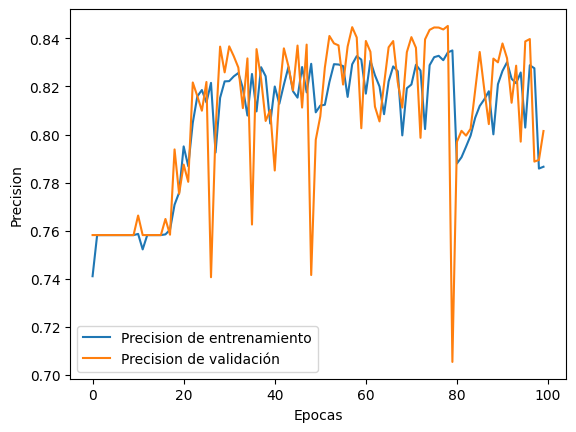

Loss: 0.48500314354896545
Accuracy: 0.8014746904373169


['modelo_red_neuronal.pkl']

In [17]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=1234, stratify=y, shuffle=True)


scaler_final=StandardScaler()
X_train_scaled=scaler_final.fit_transform(X_train)
X_test_scaled=scaler_final.transform(X_test)

y_train_ajustado=y_train-1
y_test_ajustado=y_test-1

y_train_cat=to_categorical(y_train_ajustado, 2)
y_test_cat=to_categorical(y_test_ajustado, 2)


model=Sequential([
    Dense(128,activation='relu',kernel_regularizer=l2(0.001),input_shape=(17,)),
    Dropout(0.15),
    Dense(64,activation='relu',kernel_regularizer=l2(0.001)),
    Dropout(0.10),
    Dense(32,activation='relu',kernel_regularizer=l2(0.001)),
    Dropout(0.10),
    Dense(16,activation='relu',kernel_regularizer=l2(0.001)),
    Dropout(0.15),
    Dense(2,activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['accuracy'])


history=model.fit(X_train_scaled,y_train_cat,validation_data=(X_test_scaled, y_test_cat),
                  epochs=100, batch_size=2048, verbose=0)

plt.plot(history.history['loss'], label='Perdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Perdida de validación')
plt.xlabel('Epocas')
plt.ylabel('Perdida')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Precision de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precision de validación')
plt.ylabel('Precision')
plt.xlabel('Epocas')
plt.legend()
plt.show()

loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("Loss:", loss)
print("Accuracy:", accuracy)







joblib.dump(scaler_final, "scaler_red_neuronal.pkl")
joblib.dump(model, "modelo_red_neuronal.pkl")

Prueba eliminando registros para balancear clases.

El plan es eliminar 40000 registros del target 1, de forma aleatoria ya que eso representa el 31.8 % de los datos completos del dataframe DF, esto nos dará: 55112 registros con el target 1 (64.49 %) y 30337 registros con el target 2 (35.5%), dejando el dataset con 85 449 registros (68.1 % del conjunto anterior). El único problema de este enfoque es que estamos perdiendo una gran cantidad de información.

In [ ]:
import pandas as pd

nkill = 40000 #número de registros que vamos a mochar
target1=DF[DF['target']==1] #seleccionamos todos los registros de target 1
indicesKill=target1.sample(n=nkill, random_state=42).index #los vamos a eliminar por índice, pero de forma aleatoria con una mestra del tamaño de 40000, ponemos la semilla para que sea reproducible
DFNew = DF.drop(indicesKill) #eliminamos los 40000 indices


In [ ]:
DF22=DFNew.drop(columns=["var1","target","var17"]) #preparamos el nuevo dataframe para entrenar despues
y22=DFNew["target"] #nuevo y

In [ ]:
DFNew["target"].value_counts(normalize=True)*100 #checamos la nueva proporción



,proportion
target,
1,64.496951
2,35.503049


Random forest con K-folds

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
#repetimos el mismo modelo que en el caso anterior pero esta vez el nuevo dataframe tiene una proporcion de clases mas balanceada y
#una columna menos (var1) ya que se sospecha que al tener muchos valores repetidos este afectando el rendimiento similar a la var17
X_train_valid, X_test, y_train_valid, y_test = train_test_split(DF22, y22, test_size=0.2, random_state=42, stratify=y22,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

accuracies = []
sizes = []


fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid):
  print(f"\n--- Fold {fold_num}---")
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]


  rf = RandomForestClassifier(n_estimators=150, random_state=123)

  scaler = MinMaxScaler()
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir
  rf.fit(X_train_scaled, y_train)



  y_pred = rf.predict(X_test_scaled)
  acc = accuracy_score(y_valid, y_pred)
  print(classification_report(y_valid, y_pred))
  print(confusion_matrix(y_valid, y_pred))
  accuracies.append(acc)
  sizes.append(len(y_valid))
  fold_num += 1
weighted_avg_acc = np.average(accuracies, weights=sizes)
print("\nPrecisiones por fold:", accuracies)
print("Tamaños por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))






--- Fold 1---
              precision    recall  f1-score   support

           1       0.94      0.96      0.95      8818
           2       0.92      0.89      0.90      4854

    accuracy                           0.93     13672
   macro avg       0.93      0.92      0.92     13672
weighted avg       0.93      0.93      0.93     13672

[[8423  395]
 [ 540 4314]]

--- Fold 2---
              precision    recall  f1-score   support

           1       0.94      0.96      0.95      8818
           2       0.92      0.88      0.90      4854

    accuracy                           0.93     13672
   macro avg       0.93      0.92      0.92     13672
weighted avg       0.93      0.93      0.93     13672

[[8460  358]
 [ 574 4280]]

--- Fold 3---
              precision    recall  f1-score   support

           1       0.93      0.96      0.95      8818
           2       0.92      0.88      0.90      4854

    accuracy                           0.93     13672
   macro avg       0.93      

Las métricas mejoran respecto al caso del balance de clases anterior, pero es apenas minimo.

RandomForest con PCA y dataframe reducido

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.decomposition import PCA

X_train_valid, X_test, y_train_valid, y_test = train_test_split(DF22, y22, test_size=0.2, random_state=42, stratify=y22,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

accuracies = []
sizes = []



fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid):
  print(f"\n--- Fold {fold_num}---")
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]


  clf1 = RandomForestClassifier()

  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir

  pca = PCA(n_components=10, random_state=42)
  X_train_pca = pca.fit_transform(X_train_scaled) # Se entrena SOLO con el train del fold
  X_valid_pca = pca.transform(X_test_scaled)


  clf1.fit(X_train_pca, y_train)

  yp=clf1.predict(X_valid_pca)
  acc = accuracy_score(y_valid, yp)
  print(classification_report(y_valid, yp))
  print(confusion_matrix(y_valid, yp))
  accuracies.append(acc)
  sizes.append(len(y_valid))
  fold_num += 1
weighted_avg_acc = np.average(accuracies, weights=sizes)
print("\nPrecisiones por fold:", accuracies)
print("Tama~nos por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))


--- Fold 1---
              precision    recall  f1-score   support

           1       0.91      0.96      0.93      8818
           2       0.91      0.82      0.86      4854

    accuracy                           0.91     13672
   macro avg       0.91      0.89      0.90     13672
weighted avg       0.91      0.91      0.91     13672

[[8422  396]
 [ 875 3979]]

--- Fold 2---
              precision    recall  f1-score   support

           1       0.90      0.96      0.93      8818
           2       0.91      0.80      0.85      4854

    accuracy                           0.90     13672
   macro avg       0.90      0.88      0.89     13672
weighted avg       0.90      0.90      0.90     13672

[[8432  386]
 [ 973 3881]]

--- Fold 3---
              precision    recall  f1-score   support

           1       0.89      0.95      0.92      8818
           2       0.90      0.80      0.85      4854

    accuracy                           0.90     13672
   macro avg       0.90      

Las métricas de la clase minoritaria mejoraron considerablemnete respecto a las del dataset de clases desbalanceadas, pero la precisión bajo

Red neuronal profunda con dataframe reducido


--- Fold 1---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


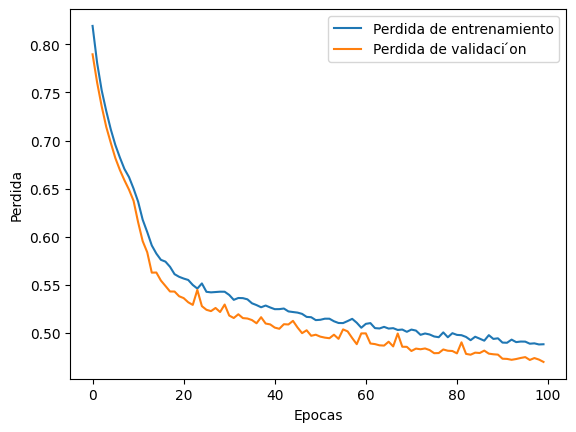

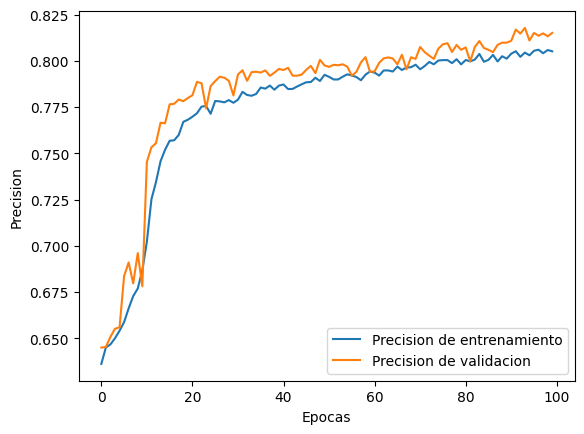

Loss: 0.4699104428291321
Accuracy: 0.8150965571403503

--- Fold 2---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


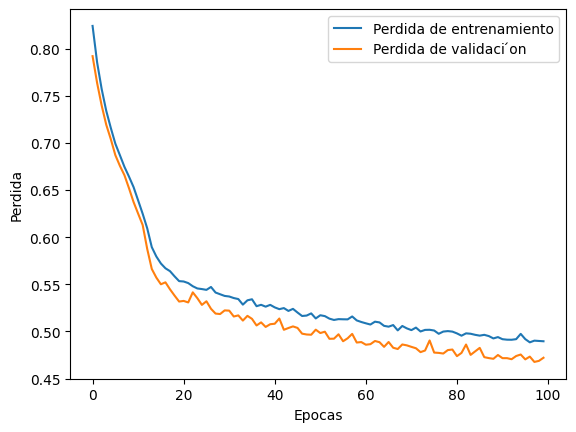

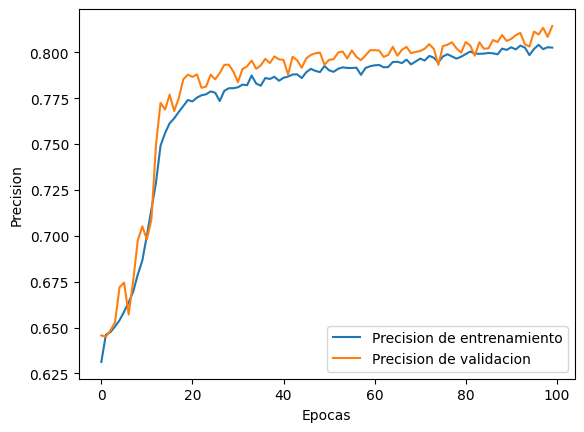

Loss: 0.4720810651779175
Accuracy: 0.8143651485443115

--- Fold 3---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


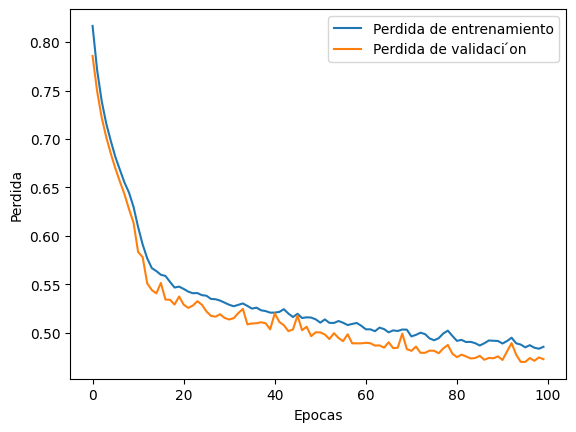

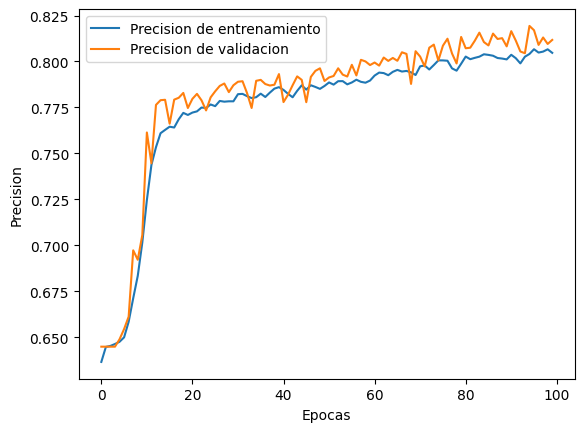

Loss: 0.47273099422454834
Accuracy: 0.8117319941520691

--- Fold 4---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


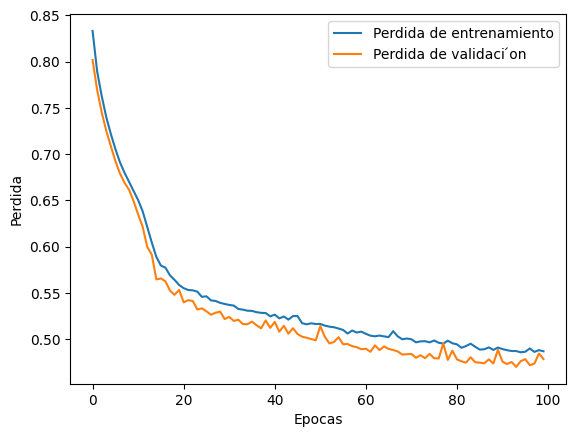

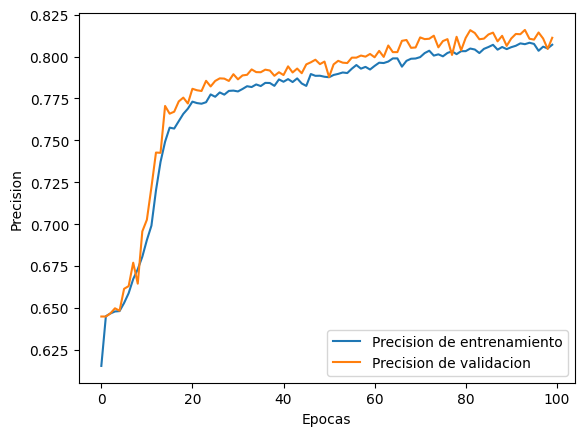

Loss: 0.47867417335510254
Accuracy: 0.8112199902534485

--- Fold 5---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


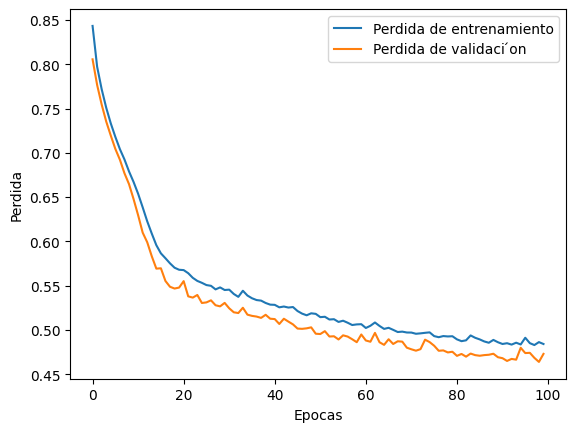

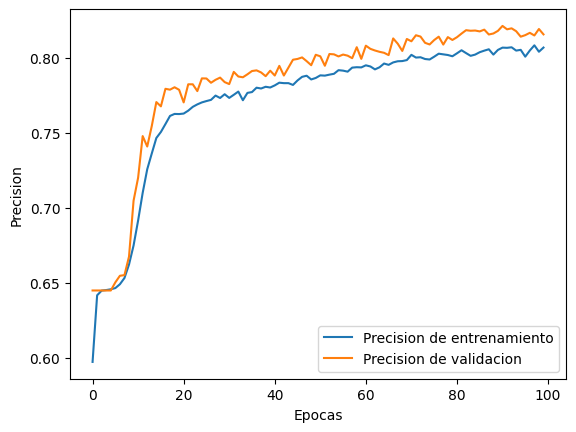

Loss: 0.47299203276634216
Accuracy: 0.8156682252883911

Precisiones por fold: [0.8150965571403503, 0.8143651485443115, 0.8117319941520691, 0.8112199902534485, 0.8156682252883911]
Tama~nos por fold: [13672, 13672, 13672, 13672, 13671]
Precisión promedio ponderada: 0.8136163530600291
Precisión promedio simple: 0.8136163830757142


In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
import numpy as np

X_train_valid, X_test, y_train_valid, y_test = train_test_split(DF22, y22, test_size=0.2, random_state=1234, stratify=y22,shuffle=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)

accuracies = []
sizes = []



fold_num = 1
for train_idx, valid_idx in skf.split(X_train_valid, y_train_valid):
  print(f"\n--- Fold {fold_num}---")
  X_train = X_train_valid.iloc[train_idx]
  X_valid = X_train_valid.iloc[valid_idx]
  y_train = y_train_valid.iloc[train_idx]
  y_valid = y_train_valid.iloc[valid_idx]



  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train) #entrenaremos con estos datos escalados
  X_test_scaled = scaler.transform(X_valid) #los usaremos para predecir


  y_trainv=y_train-1
  y_testv=y_valid-1

  y_train_cat = to_categorical(y_trainv, 2)
  y_test_cat = to_categorical(y_testv, 2)

  model = Sequential()

  model.add(Dense(128, activation='relu',kernel_regularizer=l2(0.001),input_shape=(16,)))

  model.add(Dropout(0.15))
  model.add(Dense(64, activation='relu',kernel_regularizer=l2(0.001)))

  model.add(Dropout(0.10))
  model.add(Dense(32, activation='relu',kernel_regularizer=l2(0.001)))

  model.add(Dropout(0.10))
  model.add(Dense(16, activation='relu',kernel_regularizer=l2(0.001)))

  model.add(Dropout(0.15))
  model.add(Dense(2, activation='softmax')) # 2 clases
# Compilar el modelo
  model.compile(loss='categorical_crossentropy',
            optimizer="adam",
              metrics=['accuracy'])

  history=model.fit(X_train_scaled, y_train_cat,validation_data=(X_test_scaled, y_test_cat), epochs=100,batch_size=2048,verbose=0)


  plt.plot(history.history['loss'], label='Perdida de entrenamiento')
  plt.plot(history.history['val_loss'], label='Perdida de validación')
  plt.xlabel('Epocas')
  plt.ylabel('Perdida')
  plt.legend()
  plt.show()

  plt.plot(history.history['accuracy'], label='Precision de entrenamiento')
  plt.plot(history.history['val_accuracy'], label='Precision de validación')
  plt.ylabel('Precision')
  plt.xlabel('Epocas')
  plt.legend()
  plt.show()

  loss, accuracy = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
  print("Loss:", loss)
  print("Accuracy:", accuracy)

  accuracies.append(accuracy)
  sizes.append(len(y_valid))
  fold_num += 1
weighted_avg_acc = np.average(accuracies, weights=sizes)
print("\nPrecisiones por fold:", accuracies)
print("Tamaños por fold:", sizes)
print("Precisión promedio ponderada:", weighted_avg_acc)
print("Precisión promedio simple:", np.mean(accuracies))


El rendimiento es muy similar al caso de las clases de 75 % vs 25%, no obstante para este caso la presición disminuyo, por lo que no es conveniente eliminar la columna var1 para las redes neuronales.

Relexión sobre el uso de modelo LLM

Este trabajo me dió la oportunidad de experimentar lo que es estar de cero frente a un archivo de datos completamente nuevo, similar a lo que se vería en la industria y me ha dado un punto de vista respecto al trabajo de un científico de datos. Durante del proyecto, me base principalemnte en los códigos de las clases del curso, sin embargo realicé modificaciones conforme a las ideas que me iban surgiendo para limpiar el conjunto de datos o entrenar los modelos. Las idea para tratar con el conjunto de datos (es decir limpiarlos, transformar los datos a numéricos, cambiar puntos, comas, etc) vinieron de mi propio analisis de los datos, sin embargo para llevar a cabo algunas de estas ideas recurri a la IA para preguntar sobre sintáxis de algo que no recordaba o que me respondiera dudas respecto a un algoritmo o a posibles hipótesis de los datos y su comportamiento, de esta manera reflexionando su opinión y la mía seguí un propio plan de acción. Recibí apoyo de parte de estos modelos cuando me equivoque al estandarizar los datos antes de dividirlos en conjuntos de prueba y entrenamiento (a pesar de que el profesor lo dijo en clase, no lo recordé en su momento), y en la inclusión de parámetros que no tenía frescos para optimizar el rendimiento de una GPU (como el batch_size) para la red neuronal.
El uso de los modelos de LLM en este proyecto ha sido únicamente de asistencia mínima, dejando la mayor parte del trabajo de limpieza, entrenamiento y validación en mi propia escritura (y códigos vistos en clase y tareas).